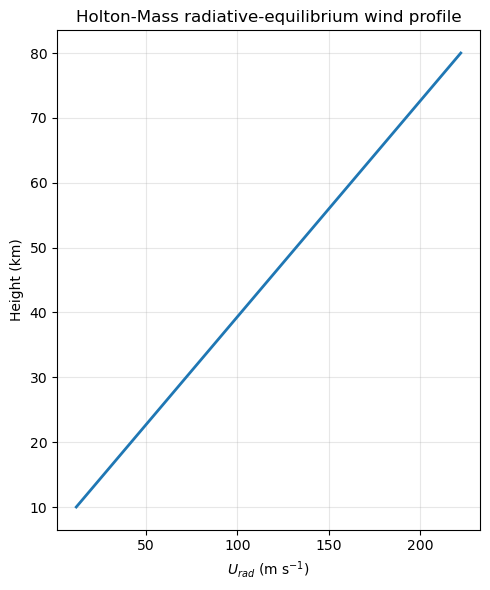

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# HM76 urad profile
# =========================================================
dz = 1000.0
imax = 71

z = dz * np.arange(imax) + 10000.0   # m
z_km = z / 1000.0

urad_hm = 12.0 + 0.003 * (z - 10000.0)   # m/s
# : urad_hm = 12.0 + 3.0 * (z_km - 10.0)

plt.figure(figsize=(5, 6))
plt.plot(urad_hm, z_km, linewidth=2)
plt.xlabel(r'$U_{rad}$ (m s$^{-1}$)')
plt.ylabel('Height (km)')
plt.title('Holton-Mass radiative-equilibrium wind profile')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

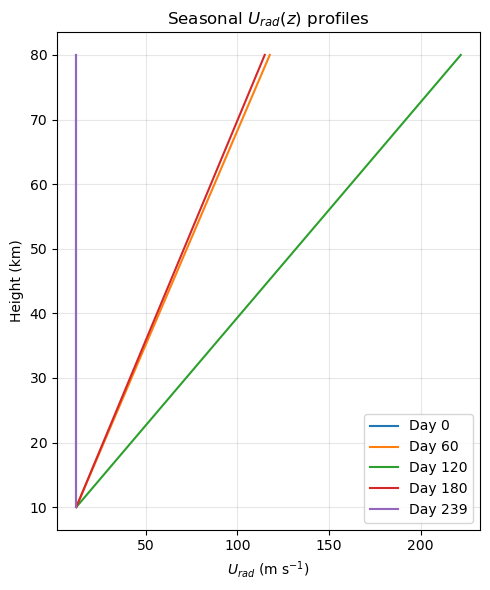

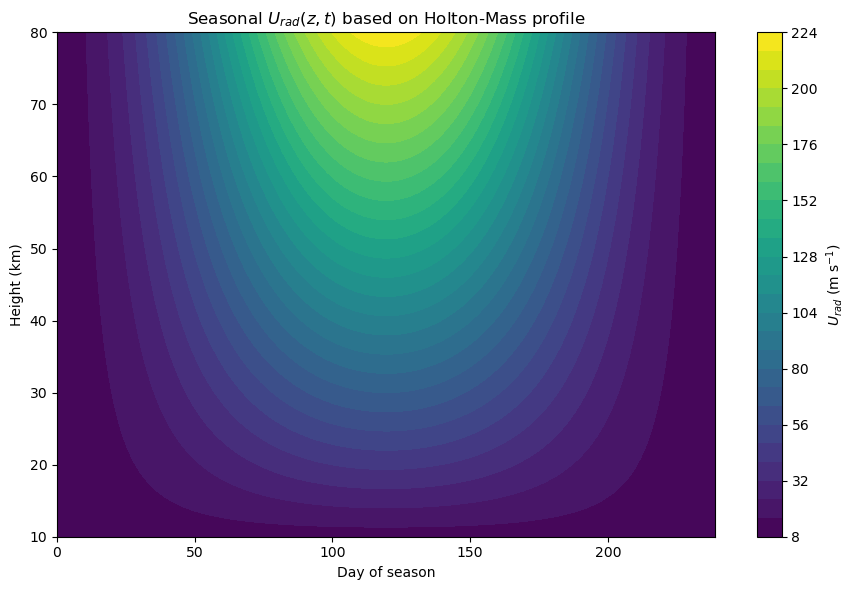

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# vertical grid
# =========================================================
dz = 1000.0
imax = 71

z = dz * np.arange(imax) + 10000.0   # m
z_km = z / 1000.0

# =========================================================
# HM76 urad profile
# =========================================================
urad_hm = 12.0 + 0.003 * (z - 10000.0)   # m/s
u_base = 12.0   # use 10-km value as baseline

# =========================================================
# time axis for one winter season
# =========================================================
n_days = 240
t_days = np.arange(n_days)

# =========================================================
# seasonal factor S(t)
# 0 at beginning/end of season, 1 at midwinter
# =========================================================
S = 0.5 * (1.0 - np.cos(2.0 * np.pi * t_days / (n_days - 1)))

# =========================================================
# build U_rad(z,t)
# preserve HM vertical structure, modulate anomaly from 12 m/s
# =========================================================
urad_seasonal = np.zeros((imax, n_days))

for it in range(n_days):
    urad_seasonal[:, it] = u_base + S[it] * (urad_hm - u_base)

# =========================================================
# plot a few time slices first (optional)
# =========================================================
plt.figure(figsize=(5, 6))
for day in [0, 60, 120, 180, 239]:
    plt.plot(urad_seasonal[:, day], z_km, label=f'Day {day}')
plt.xlabel(r'$U_{rad}$ (m s$^{-1}$)')
plt.ylabel('Height (km)')
plt.title('Seasonal $U_{rad}(z)$ profiles')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# time-height plot
# =========================================================
T, Z = np.meshgrid(t_days, z_km)

plt.figure(figsize=(9, 6))
cf = plt.contourf(T, Z, urad_seasonal, levels=31)
plt.colorbar(cf, label=r'$U_{rad}$ (m s$^{-1}$)')
plt.xlabel('Day of season')
plt.ylabel('Height (km)')
plt.title(r'Seasonal $U_{rad}(z,t)$ based on Holton-Mass profile')
plt.tight_layout()
plt.show()

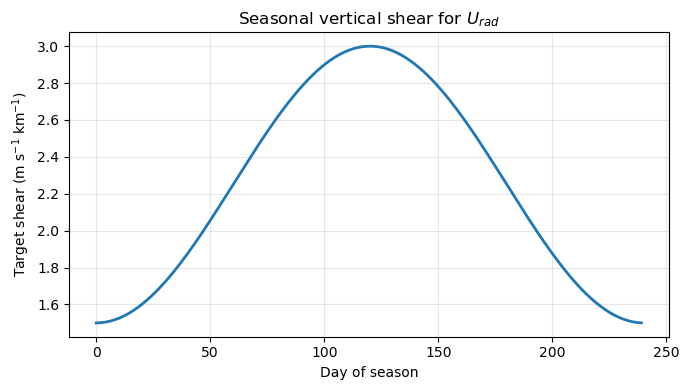

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# time axis
# =========================================================
n_days = 240
t_days = np.arange(n_days)

# peak in midwinter
t_peak = 120

# shear(t) in m/s/km
shear_min = 1.5
shear_max = 3.0
shear_mean = 0.5 * (shear_min + shear_max)
shear_amp  = 0.5 * (shear_max - shear_min)

shear_t = shear_mean + shear_amp * np.cos(2.0 * np.pi * (t_days - t_peak) / n_days)

plt.figure(figsize=(7,4))
plt.plot(t_days, shear_t, linewidth=2)
plt.xlabel('Day of season')
plt.ylabel('Target shear (m s$^{-1}$ km$^{-1}$)')
plt.title('Seasonal vertical shear for $U_{rad}$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

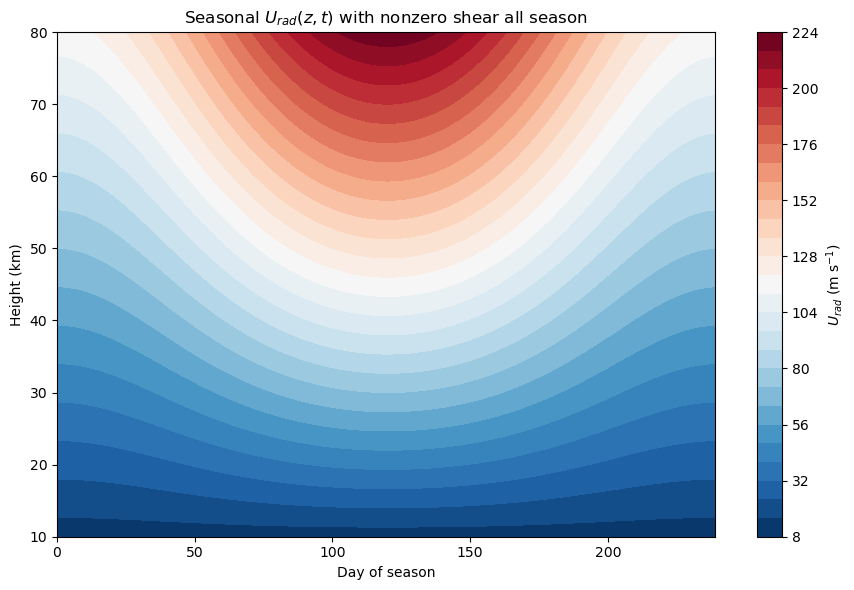

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# vertical grid
# =========================================================
dz = 1000.0
imax = 71
z = dz * np.arange(imax) + 10000.0   # m
z_km = z / 1000.0

# =========================================================
# time axis
# =========================================================
n_days = 240
t_days = np.arange(n_days)
t_peak = 120

# =========================================================
# seasonal shear(t): always positive
# =========================================================
shear_min = 1.5   # m/s/km
shear_max = 3.0   # m/s/km
shear_mean = 0.5 * (shear_min + shear_max)
shear_amp  = 0.5 * (shear_max - shear_min)

shear_t = shear_mean + shear_amp * np.cos(2.0 * np.pi * (t_days - t_peak) / n_days)

# =========================================================
# build U_rad(z,t)
# U_rad = 12 m/s at 10 km, then grows with seasonal shear
# =========================================================
urad_seasonal = np.zeros((imax, n_days))

for it in range(n_days):
    urad_seasonal[:, it] = 12.0 + shear_t[it] * (z_km - 10.0)

# =========================================================
# time-height plot
# =========================================================
T, Z = np.meshgrid(t_days, z_km)

plt.figure(figsize=(9, 6))
cf = plt.contourf(T, Z, urad_seasonal, levels=31, cmap='RdBu_r')  #  'viridis' colormap
plt.colorbar(cf, label=r'$U_{rad}$ (m s$^{-1}$)')
plt.xlabel('Day of season')
plt.ylabel('Height (km)')
plt.title(r'Seasonal $U_{rad}(z,t)$ with nonzero shear all season')
plt.tight_layout()
plt.show()

shear_t min/max = 0.5 3.6
taper starts at index 185, height = 46.93 km
model top height = 109.80 km


urad_hm_taper_2d shape = (501, 992)
urad_hm_taper_3d shape = (501, 42, 992)
min/max tapered urad = 12.0 174.96808054802045


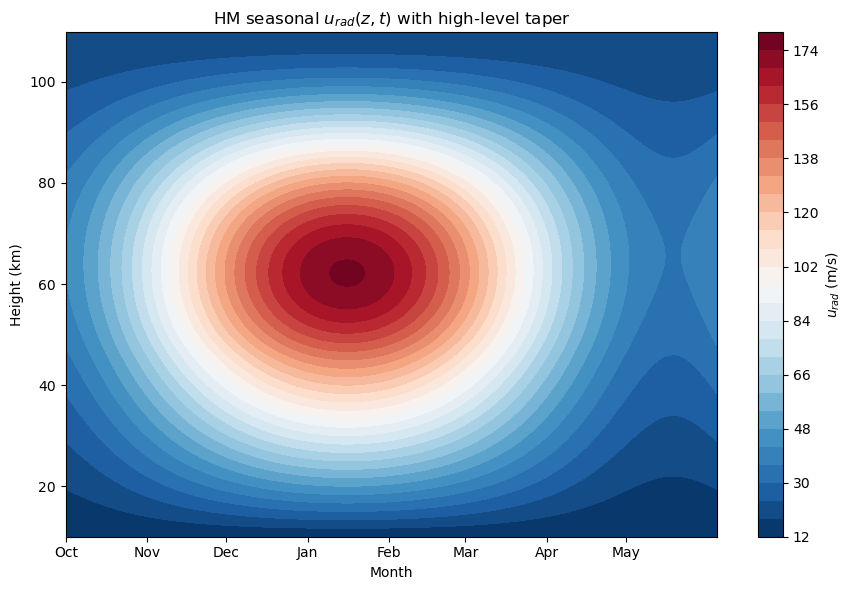

z index 110 corresponds to height = 31.96 km


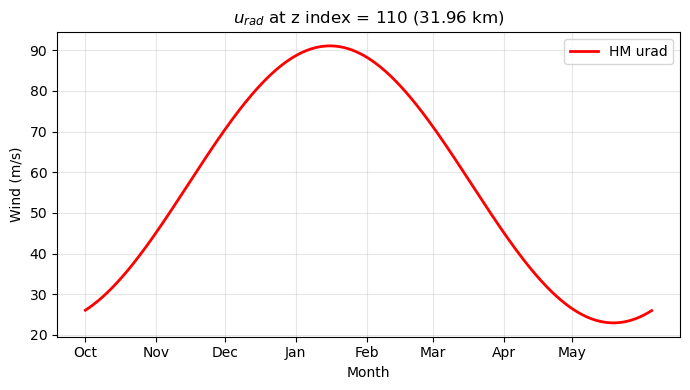

In [3]:
import numpy as np
import matplotlib.pyplot as plot
import netCDF4 as nc

# =========================================================
# user settings
# =========================================================
nyear = 42
zdim  = 501
ntime = 992   # Oct-May, 6-hourly

u10 = 12.0
shear0 = 3.0
amp = 0.2

# peak around mid-January
t_peak = 107 * 4

# taper settings
z0_km = 47.0     # start taper above this height
u_top = 20.0     # target value at top level after taper

# =========================================================
# vertical grid
# =========================================================
hhh = np.arange(0, zdim, 1) * (100.0 / zdim) + 10.0   # km

# =========================================================
# time axis
# =========================================================
t_idx = np.arange(ntime)
t_days = t_idx / 4.0

# seasonal shear
shear_min = 0.5
shear_max = 3.6

phase = np.cos(2.0 * np.pi * (t_idx - t_peak) / ntime)
phase01 = 0.5 * (phase + 1.0)

shear_t = shear_min + (shear_max - shear_min) * phase01
print("shear_t min/max =", shear_t.min(), shear_t.max())

# =========================================================
# HM-style urad(z,t)
# =========================================================
urad_hm_2d = np.zeros((zdim, ntime))
for it in range(ntime):
    urad_hm_2d[:, it] = u10 + shear_t[it] * (hhh - 10.0)

# =========================================================
# high-level taper
# below z0_km: unchanged
# above z0_km: smoothly transition to u_top at model top
# =========================================================
urad_hm_taper_2d = urad_hm_2d.copy()

i0 = np.argmin(np.abs(hhh - z0_km))
z_top = hhh[-1]

print(f"taper starts at index {i0}, height = {hhh[i0]:.2f} km")
print(f"model top height = {z_top:.2f} km")

for it in range(ntime):
    u0 = urad_hm_2d[i0, it]   # value at taper start

    for k in range(i0, zdim):
        s = (hhh[k] - hhh[i0]) / (z_top - hhh[i0])   # 0 -> 1
        s = np.clip(s, 0.0, 1.0)

        # cosine smoothstep: 1 at start, 0 at top
        w = 0.5 * (1.0 + np.cos(np.pi * s))

        urad_hm_taper_2d[k, it] = w * urad_hm_2d[k, it] + (1.0 - w) * u_top

# =========================================================
# expand to (zdim, nyear, 992)
# =========================================================
urad_hm_taper_3d = np.repeat(urad_hm_taper_2d[:, np.newaxis, :], nyear, axis=1)

print("urad_hm_taper_2d shape =", urad_hm_taper_2d.shape)
print("urad_hm_taper_3d shape =", urad_hm_taper_3d.shape)
print("min/max tapered urad =", np.nanmin(urad_hm_taper_3d), np.nanmax(urad_hm_taper_3d))

# =========================================================
# t-z plot
# =========================================================
T, Z = np.meshgrid(t_days, hhh)

plot.figure(figsize=(9, 6))
cf = plot.contourf(T, Z, urad_hm_taper_2d, levels=31,cmap='RdBu_r')
plot.colorbar(cf, label=r'$u_{rad}$ (m/s)')
plot.xticks(
    ticks=[0, 31, 61, 92, 123, 152, 183, 213],
    labels=['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May']
)
plot.xlabel('Month')
plot.ylabel('Height (km)')
# plot.ylim(10,60)
plot.title(r'HM seasonal $u_{rad}(z,t)$ with high-level taper')
plot.tight_layout()
plot.show()

# =========================================================
# plot urad at z index = 110
# =========================================================
k_plot = 110
print(f"z index {k_plot} corresponds to height = {hhh[k_plot]:.2f} km")

plot.figure(figsize=(7, 4))
plot.plot(t_days, urad_hm_taper_2d[k_plot, :], color='red', linewidth=2, label='HM urad')
plot.xticks(
    ticks=[0, 31, 61, 92, 123, 152, 183, 213],
    labels=['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May']
)
plot.xlabel('Month')
plot.ylabel('Wind (m/s)')
plot.title(fr'$u_{{rad}}$ at z index = {k_plot} ({hhh[k_plot]:.2f} km)')
plot.grid(alpha=0.3)
plot.legend()
plot.tight_layout()
plot.show()

In [39]:
# =========================================================
# save to netCDF
# =========================================================
out_file = f'/mnt/winds/home/smliu01/0.1dmodel_2025/urad/urad_hm_taper_{zdim}_{nyear}.nc'

ncfile = nc.Dataset(out_file, mode='w', format='NETCDF4')

# dimensions
ncfile.createDimension('height', zdim)
ncfile.createDimension('year', nyear)
ncfile.createDimension('time', ntime)

# coordinate variables (optional but recommended)
height_var = ncfile.createVariable('height', np.float32, ('height',))
year_var   = ncfile.createVariable('year', np.int32, ('year',))
time_var   = ncfile.createVariable('time', np.int32, ('time',))

# main variable
urad_var = ncfile.createVariable('urad', np.float32, ('height', 'year', 'time'))

# write coordinates
height_var[:] = hhh
year_var[:]   = np.arange(nyear)
time_var[:]   = np.arange(ntime)

# attributes
height_var.units = 'km'
height_var.long_name = 'height'
year_var.long_name = 'year index'
time_var.long_name = '6-hourly time index from Oct 1'
urad_var.units = 'm s-1'
urad_var.long_name = 'HM seasonal urad with high-level taper'

# write data
urad_var[:] = urad_hm_taper_3d.astype(np.float32)

ncfile.close()

print("saved to:", out_file)

saved to: /mnt/winds/home/smliu01/0.1dmodel_2025/urad/urad_hm_taper_501_42.nc


shear_t min/max = 0.5 3.6
urad_hm_2d shape = (501, 992)
urad_hm_3d shape = (501, 42, 992)
min/max urad = 12.0 371.2814371257485


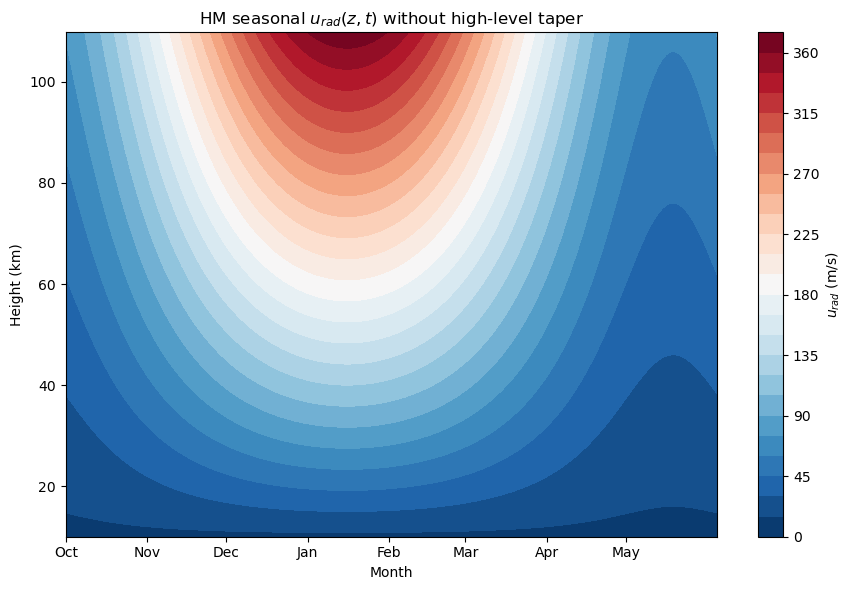

z index 110 corresponds to height = 31.96 km


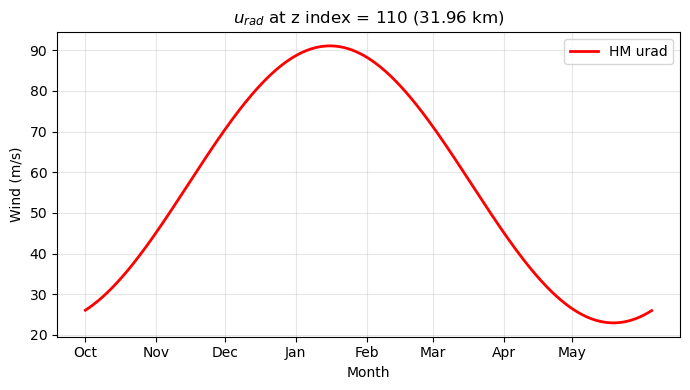

saved to: /mnt/winds/home/smliu01/0.1dmodel_2025/urad/urad_hm_notaper_501_42.nc


In [70]:
import numpy as np
import matplotlib.pyplot as plot
import netCDF4 as nc

# =========================================================
# user settings
# =========================================================
nyear = 42
zdim  = 501
ntime = 992   # Oct-May, 6-hourly

u10 = 12.0
shear0 = 3.0
amp = 0.2

# peak around mid-January
t_peak = 107 * 4

# =========================================================
# vertical grid
# =========================================================
hhh = np.arange(0, zdim, 1) * (100.0 / zdim) + 10.0   # km

# =========================================================
# time axis
# =========================================================
t_idx = np.arange(ntime)
t_days = t_idx / 4.0

# seasonal shear
shear_min = 0.5
shear_max = 3.6

phase = np.cos(2.0 * np.pi * (t_idx - t_peak) / ntime)
phase01 = 0.5 * (phase + 1.0)

shear_t = shear_min + (shear_max - shear_min) * phase01
print("shear_t min/max =", shear_t.min(), shear_t.max())

# =========================================================
# HM-style urad(z,t)
# no taper version: keep original profile at all heights
# =========================================================
urad_hm_2d = np.zeros((zdim, ntime))
for it in range(ntime):
    urad_hm_2d[:, it] = u10 + shear_t[it] * (hhh - 10.0)

# =========================================================
# expand to (zdim, nyear, 992)
# =========================================================
urad_hm_3d = np.repeat(urad_hm_2d[:, np.newaxis, :], nyear, axis=1)

print("urad_hm_2d shape =", urad_hm_2d.shape)
print("urad_hm_3d shape =", urad_hm_3d.shape)
print("min/max urad =", np.nanmin(urad_hm_3d), np.nanmax(urad_hm_3d))

# =========================================================
# t-z plot
# =========================================================
T, Z = np.meshgrid(t_days, hhh)

plot.figure(figsize=(9, 6))
cf = plot.contourf(T, Z, urad_hm_2d, levels=31, cmap='RdBu_r')
plot.colorbar(cf, label=r'$u_{rad}$ (m/s)')
plot.xticks(
    ticks=[0, 31, 61, 92, 123, 152, 183, 213],
    labels=['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May']
)
plot.xlabel('Month')
plot.ylabel('Height (km)')
# plot.ylim(10,60)
plot.title(r'HM seasonal $u_{rad}(z,t)$ without high-level taper')
plot.tight_layout()
plot.show()

# =========================================================
# plot urad at z index = 110
# =========================================================
k_plot = 110
print(f"z index {k_plot} corresponds to height = {hhh[k_plot]:.2f} km")

plot.figure(figsize=(7, 4))
plot.plot(t_days, urad_hm_2d[k_plot, :], color='red', linewidth=2, label='HM urad')
plot.xticks(
    ticks=[0, 31, 61, 92, 123, 152, 183, 213],
    labels=['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May']
)
plot.xlabel('Month')
plot.ylabel('Wind (m/s)')
plot.title(fr'$u_{{rad}}$ at z index = {k_plot} ({hhh[k_plot]:.2f} km)')
plot.grid(alpha=0.3)
plot.legend()
plot.tight_layout()
plot.show()

# =========================================================
# save to netCDF
# =========================================================
out_file = f'/mnt/winds/home/smliu01/0.1dmodel_2025/urad/urad_hm_notaper_{zdim}_{nyear}.nc'

ncfile = nc.Dataset(out_file, mode='w', format='NETCDF4')

# dimensions
ncfile.createDimension('height', zdim)
ncfile.createDimension('year', nyear)
ncfile.createDimension('time', ntime)

# coordinate variables (optional but recommended)
height_var = ncfile.createVariable('height', np.float32, ('height',))
year_var   = ncfile.createVariable('year', np.int32, ('year',))
time_var   = ncfile.createVariable('time', np.int32, ('time',))

# main variable
urad_var = ncfile.createVariable('urad', np.float32, ('height', 'year', 'time'))

# write coordinates
height_var[:] = hhh
year_var[:]   = np.arange(nyear)
time_var[:]   = np.arange(ntime)

# attributes
height_var.units = 'km'
height_var.long_name = 'height'
year_var.long_name = 'year index'
time_var.long_name = '6-hourly time index from Oct 1'
urad_var.units = 'm s-1'
urad_var.long_name = 'HM seasonal urad without high-level taper'

# write data
urad_var[:] = urad_hm_3d.astype(np.float32)

ncfile.close()

print("saved to:", out_file)

In [8]:
import netCDF4 as nc
import numpy as np

#  netCDF 
ncfile = nc.Dataset('/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing_2026/urad_501.nc', mode='r')

# 
print(list(ncfile.variables.keys()))

# 
urad = ncfile.variables['urad'][:]

ncfile.close()


['urad']


In [14]:
zdim = 501

height = np.zeros(97)
plev = np.zeros(97)
h1d = np.zeros(zdim)
dz = 500.
hh = 7000.
dz1d = 100000/(zdim-1)
for k in range(97):
    height[k] = k*dz
    plev[k] = 1000*np.exp(-height[k]/hh)
for k in range(zdim):
    h1d[k] = dz1d*k+10000.

print(height[96])
print(h1d[0])

48000.0
10000.0


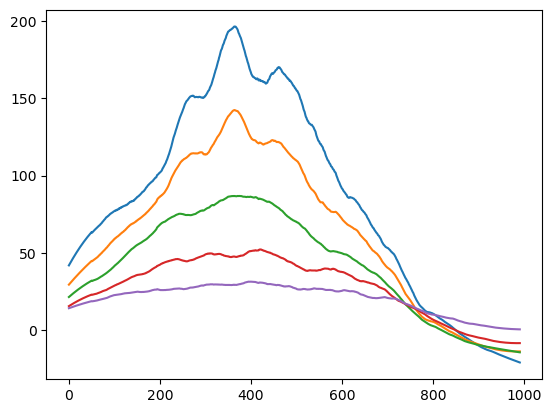

In [ ]:
import matplotlib.pyplot as plt
plt.plot(urad[180,1,:])
# plt.plot(urad[170,1,:])
plt.plot(urad[160,1,:])
#plt.plot(urad[150,1,:])
plt.plot(urad[130,1,:])
plt.plot(urad[110,1,:])
plt.plot(urad[80,1,:])
plt.plot(urad[50,1,:])

Anchor levels and heights:
  k= 50, z= 19.98 km
  k= 80, z= 25.97 km
  k=110, z= 31.96 km
  k=130, z= 35.95 km
  k=160, z= 41.94 km
  k=180, z= 45.93 km
urad_clim shape = (501, 992)
common t_peak = 374 day = 93.5
k= 50, z= 19.98 km, t_peak= 374, u_min=  15.207, u_peak=  29.708, u_end=   0.650, p_pre= 0.90, p_post= 1.30, mse=   1.4470
k= 80, z= 25.97 km, t_peak= 374, u_min=  17.261, u_peak=  47.956, u_end=  -8.346, p_pre= 1.00, p_post= 1.60, mse=   4.3465
k=110, z= 31.96 km, t_peak= 374, u_min=  23.808, u_peak=  86.864, u_end= -13.868, p_pre= 1.40, p_post= 2.40, mse=   8.4865
k=130, z= 35.95 km, t_peak= 364, u_min=  32.660, u_peak= 142.435, u_end= -13.717, p_pre= 2.20, p_post= 2.90, mse=  66.8143
k=160, z= 41.94 km, t_peak= 364, u_min=  46.728, u_peak= 196.527, u_end= -19.849, p_pre= 3.00, p_post= 3.00, mse= 157.8037
k=180, z= 45.93 km, t_peak= 366, u_min=  60.839, u_peak= 250.254, u_end= -22.991, p_pre= 3.00, p_post= 3.00, mse= 385.1532
urad_new_2d shape = (501, 992)
urad_new_3d shape 

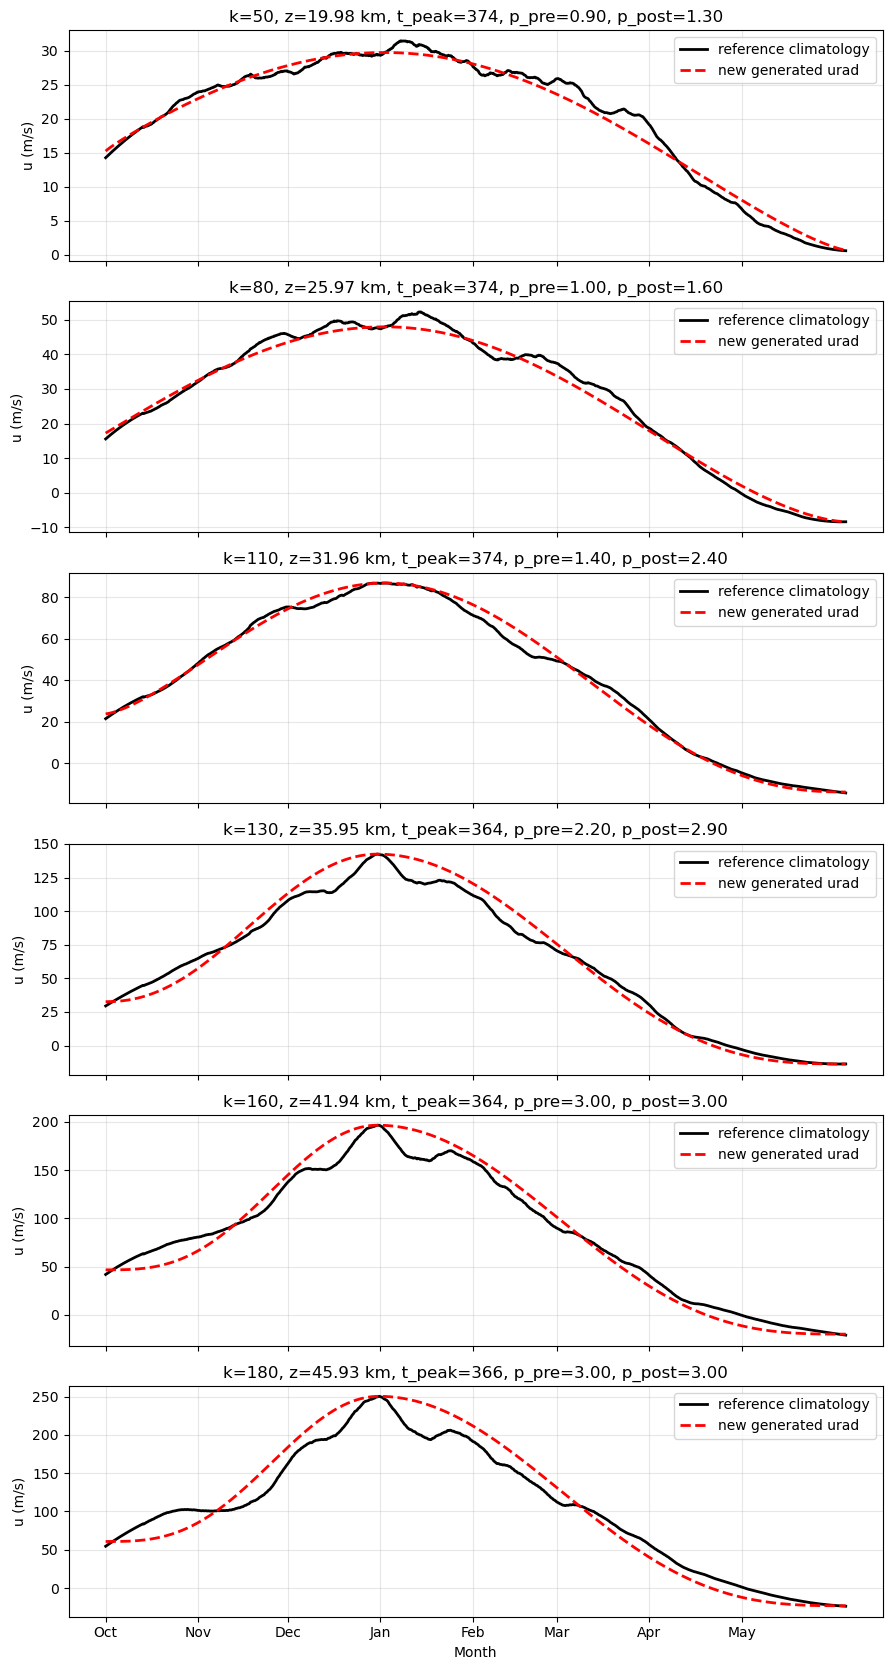

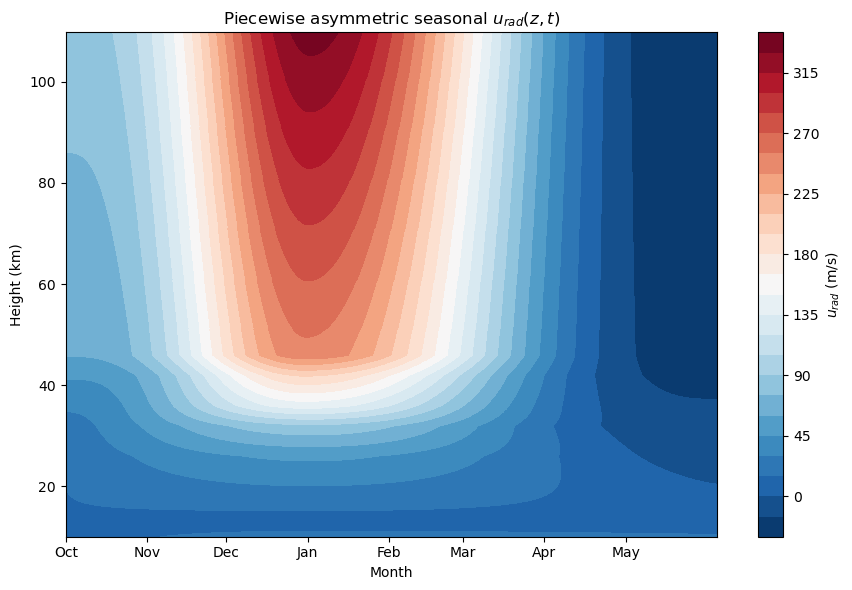

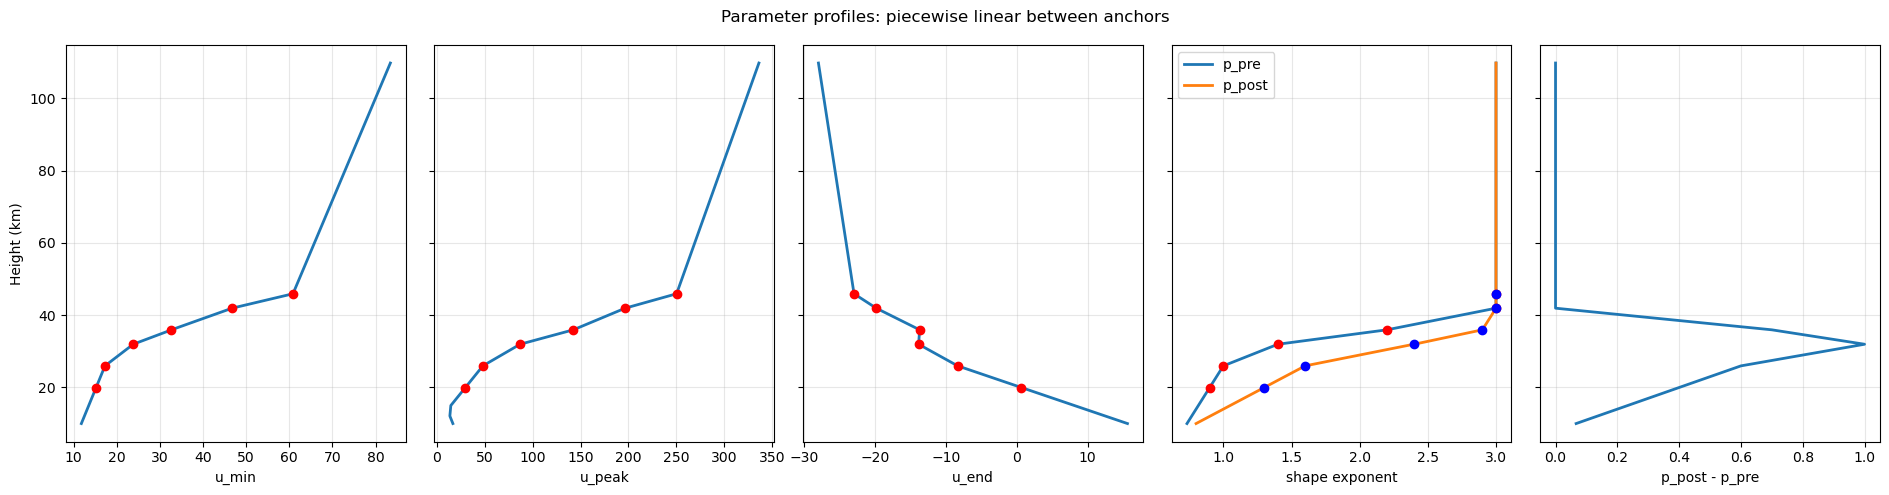

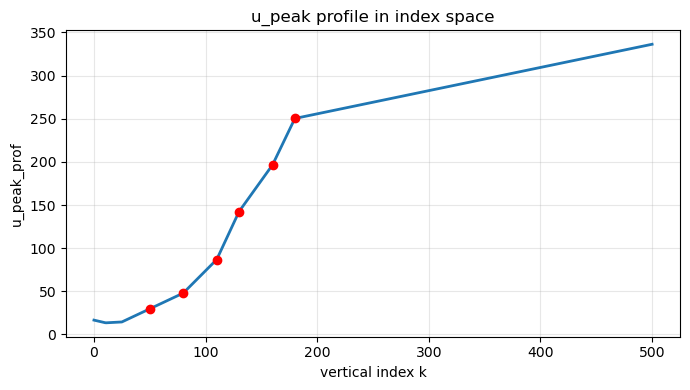

saved to: /mnt/winds/home/smliu01/0.1dmodel_2025/urad/urad_piecewise_asym_piecewiseLinear_501_42.nc


In [68]:
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc

# =========================================================
# user settings
# =========================================================
nyear = 42
zdim  = 501
ntime = 992

ref_file = f'/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/urad_{zdim}.nc'
out_file = f'/mnt/winds/home/smliu01/0.1dmodel_2025/urad/urad_piecewise_asym_piecewiseLinear_{zdim}_{nyear}.nc'

# ---------------------------------------------------------
# anchors
# k_ref only defines common peak time for lower/mid levels
# ---------------------------------------------------------
k_ref = 110
anchors = [50, 80, 110, 130, 160, 180]

# use common peak time from k_ref for lower levels
use_common_peak = True

# high anchors can use their own peak time
high_anchor_set = {130, 160, 180}

# right-side extrapolation slope factor above last anchor
# 1.0 = full last-segment slope
# 0.3 = weaker extrapolation
right_slope_factor = 0.1

# vertical smoothing passes on parameter profiles
# start with 0 to preserve your piecewise-linear structure
npass_smooth = 0

# =========================================================
# helper
# =========================================================
def smooth121_1d(x, npass=3):
    x = np.asarray(x, dtype=float).copy()
    if npass <= 0:
        return x
    for _ in range(npass):
        y = x.copy()
        for i in range(1, len(x)-1):
            vals = np.array([x[i-1], x[i], x[i+1]], dtype=float)
            w = np.array([1.0, 2.0, 1.0], dtype=float)
            m = np.isfinite(vals)
            if np.any(m):
                y[i] = np.sum(vals[m] * w[m]) / np.sum(w[m])
        x = y
    return x

def piecewise_shape(t, t_peak, u_min, u_peak, u_end, p_pre, p_post, ntime):
    """
    piecewise asymmetric seasonal curve:
      before peak : rises from u_min to u_peak
      after peak  : decays from u_peak to u_end
    """
    t = np.asarray(t, dtype=float)
    y = np.zeros_like(t, dtype=float)

    # before peak
    m1 = t <= t_peak
    if np.any(m1):
        x1 = np.zeros_like(t[m1], dtype=float)
        if t_peak > 0:
            x1 = t[m1] / t_peak
        x1 = np.clip(x1, 0.0, 1.0)
        y[m1] = u_min + (u_peak - u_min) * np.sin(0.5 * np.pi * x1) ** p_pre

    # after peak
    m2 = t > t_peak
    if np.any(m2):
        denom = (ntime - 1 - t_peak)
        x2 = np.zeros_like(t[m2], dtype=float)
        if denom > 0:
            x2 = (ntime - 1 - t[m2]) / denom
        x2 = np.clip(x2, 0.0, 1.0)
        y[m2] = u_end + (u_peak - u_end) * np.sin(0.5 * np.pi * x2) ** p_post

    return y

def fit_piecewise_given_peak(y, t_peak, ntime, p_candidates=None):
    """
    Fit piecewise asymmetric curve with fixed t_peak.
    Search over p_pre, p_post on a grid.
    u_min/u_peak/u_end are grounded from data.
    """
    if p_candidates is None:
        p_candidates = np.arange(0.6, 3.01, 0.1)

    t = np.arange(len(y))
    y = np.asarray(y, dtype=float)

    u_peak = y[t_peak]
    u_min  = np.nanmean(y[:20])     # early Oct mean
    u_end  = np.nanmean(y[-20:])    # late May mean

    best = None
    best_err = np.inf

    for p_pre in p_candidates:
        for p_post in p_candidates:
            yfit = piecewise_shape(
                t=t, t_peak=t_peak,
                u_min=u_min, u_peak=u_peak, u_end=u_end,
                p_pre=p_pre, p_post=p_post,
                ntime=ntime
            )
            err = np.nanmean((y - yfit) ** 2)
            if err < best_err:
                best_err = err
                best = (u_min, u_peak, u_end, p_pre, p_post, yfit)

    return best, best_err

def interp_piecewise_linear_scaled_right(x_new, x, y, right_slope_factor=0.35):
    """
    piecewise linear interpolation between anchors
    left of first anchor: linear extrapolation with first-segment slope
    right of last anchor: linear extrapolation with reduced last-segment slope
    """
    x_new = np.asarray(x_new, dtype=float)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    y_new = np.empty_like(x_new, dtype=float)

    # left extrapolation
    slope_left = (y[1] - y[0]) / (x[1] - x[0])
    m_left = x_new <= x[0]
    y_new[m_left] = y[0] + slope_left * (x_new[m_left] - x[0])

    # interior piecewise linear interpolation
    for i in range(len(x) - 1):
        if i == 0:
            m = (x_new > x[i]) & (x_new <= x[i+1])
        else:
            m = (x_new > x[i]) & (x_new <= x[i+1])
        frac = (x_new[m] - x[i]) / (x[i+1] - x[i])
        y_new[m] = y[i] + frac * (y[i+1] - y[i])

    # exact first anchor
    y_new[x_new == x[0]] = y[0]

    # right extrapolation
    slope_right = (y[-1] - y[-2]) / (x[-1] - x[-2])
    slope_right_scaled = right_slope_factor * slope_right
    m_right = x_new > x[-1]
    y_new[m_right] = y[-1] + slope_right_scaled * (x_new[m_right] - x[-1])

    return y_new

# =========================================================
# vertical grid
# =========================================================
hhh = np.arange(zdim) * (100.0 / zdim) + 10.0   # km

print("Anchor levels and heights:")
for k in anchors:
    print(f"  k={k:3d}, z={hhh[k]:6.2f} km")

# =========================================================
# load reference
# =========================================================
ds = nc.Dataset(ref_file, 'r')
urad_ref = np.array(ds.variables['urad'][:], dtype=float)
ds.close()

# climatology over years: (z, time)
urad_clim = np.nanmean(urad_ref, axis=1)

print("urad_clim shape =", urad_clim.shape)

# =========================================================
# common peak time from k_ref
# =========================================================
if use_common_peak:
    t_peak_common = int(np.nanargmax(urad_clim[k_ref, :]))
else:
    t_peak_common = None

print("common t_peak =", t_peak_common, "day =", t_peak_common / 4.0 if t_peak_common is not None else None)

# =========================================================
# fit anchor layers
# =========================================================
anchor_params = {}

for k in anchors:
    y = urad_clim[k, :]

    if use_common_peak and (k not in high_anchor_set):
        tpk = t_peak_common
    else:
        tpk = int(np.nanargmax(y))

    best, err = fit_piecewise_given_peak(y, tpk, ntime=ntime)
    u_min, u_peak, u_end, p_pre, p_post, yfit = best

    anchor_params[k] = {
        't_peak': tpk,
        'u_min': u_min,
        'u_peak': u_peak,
        'u_end': u_end,
        'p_pre': p_pre,
        'p_post': p_post,
        'fit': yfit,
        'mse': err
    }

    print(
        f"k={k:3d}, z={hhh[k]:6.2f} km, "
        f"t_peak={tpk:4d}, "
        f"u_min={u_min:8.3f}, u_peak={u_peak:8.3f}, u_end={u_end:8.3f}, "
        f"p_pre={p_pre:5.2f}, p_post={p_post:5.2f}, mse={err:9.4f}"
    )

# =========================================================
# build parameter profiles:
# piecewise linear between anchors
# weaker linear extrapolation above last anchor
# =========================================================
k_anchor = np.array(anchors, dtype=float)
k_all = np.arange(zdim, dtype=float)

u_min_anchor  = np.array([anchor_params[k]['u_min']  for k in anchors], dtype=float)
u_peak_anchor = np.array([anchor_params[k]['u_peak'] for k in anchors], dtype=float)
u_end_anchor  = np.array([anchor_params[k]['u_end']  for k in anchors], dtype=float)
p_pre_anchor  = np.array([anchor_params[k]['p_pre']  for k in anchors], dtype=float)
p_post_anchor = np.array([anchor_params[k]['p_post'] for k in anchors], dtype=float)

u_min_prof  = interp_piecewise_linear_scaled_right(k_all, k_anchor, u_min_anchor,  right_slope_factor=right_slope_factor)
u_peak_prof = interp_piecewise_linear_scaled_right(k_all, k_anchor, u_peak_anchor, right_slope_factor=right_slope_factor)
u_end_prof  = interp_piecewise_linear_scaled_right(k_all, k_anchor, u_end_anchor,  right_slope_factor=right_slope_factor)
p_pre_prof  = interp_piecewise_linear_scaled_right(k_all, k_anchor, p_pre_anchor,  right_slope_factor=right_slope_factor)
p_post_prof = interp_piecewise_linear_scaled_right(k_all, k_anchor, p_post_anchor, right_slope_factor=right_slope_factor)

# optional light smoothing
u_min_prof  = smooth121_1d(u_min_prof,  npass=npass_smooth)
u_peak_prof = smooth121_1d(u_peak_prof, npass=npass_smooth)
u_end_prof  = smooth121_1d(u_end_prof,  npass=npass_smooth)
p_pre_prof  = smooth121_1d(p_pre_prof,  npass=npass_smooth)
p_post_prof = smooth121_1d(p_post_prof, npass=npass_smooth)

# guards
# p_pre_prof  = np.clip(p_pre_prof,  0.4, 4.0)
# p_post_prof = np.clip(p_post_prof, 0.4, 4.0)

# u_peak_prof = np.clip(u_peak_prof, 5.0, 200.0)
# u_min_prof  = np.clip(u_min_prof, -30.0, 100.0)
# u_end_prof  = np.clip(u_end_prof, -60.0, 60.0)

u_peak_prof = np.maximum(u_peak_prof, u_min_prof + 1.0)
u_peak_prof = np.maximum(u_peak_prof, u_end_prof + 1.0)

skew_like_prof = p_post_prof - p_pre_prof

# =========================================================
# generate urad(z,t)
# note: NO forced replacement of anchor layers
# =========================================================
t = np.arange(ntime)
urad_new_2d = np.zeros((zdim, ntime), dtype=float)

for k in range(zdim):
    if use_common_peak and (k <= 110):
        tpk_use = t_peak_common
    else:
        # above 110, make t_peak vary piecewise linearly from anchor t_peak
        # this avoids hardwiring all upper levels to the same peak time
        t_peak_anchor = np.array([anchor_params[kk]['t_peak'] for kk in anchors], dtype=float)
        t_peak_prof = interp_piecewise_linear_scaled_right(
            k_all, k_anchor, t_peak_anchor, right_slope_factor=0.2
        )
        tpk_use = int(np.round(t_peak_prof[k]))
        tpk_use = max(1, min(ntime - 2, tpk_use))

    urad_new_2d[k, :] = piecewise_shape(
        t=t,
        t_peak=tpk_use,
        u_min=u_min_prof[k],
        u_peak=u_peak_prof[k],
        u_end=u_end_prof[k],
        p_pre=p_pre_prof[k],
        p_post=p_post_prof[k],
        ntime=ntime
    )

# expand to all years
urad_new_3d = np.repeat(urad_new_2d[:, np.newaxis, :], nyear, axis=1)

print("urad_new_2d shape =", urad_new_2d.shape)
print("urad_new_3d shape =", urad_new_3d.shape)
print("new urad min/max =", np.nanmin(urad_new_3d), np.nanmax(urad_new_3d))

# =========================================================
# plots
# =========================================================
month_ticks = [0, 31*4, 61*4, 92*4, 123*4, 151*4, 182*4, 213*4]
month_labels = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May']
t_days = np.arange(ntime) / 4.0

# -------------------------
# anchor comparison
# -------------------------
fig, axes = plt.subplots(len(anchors), 1, figsize=(9, 2.8*len(anchors)), sharex=True)
if len(anchors) == 1:
    axes = [axes]

for ax, k in zip(axes, anchors):
    ax.plot(t_days, urad_clim[k, :], color='k', lw=2, label='reference climatology')
    ax.plot(t_days, urad_new_2d[k, :], color='red', lw=2, ls='--', label='new generated urad')
    ax.set_ylabel('u (m/s)')
    ax.set_title(
        f'k={k}, z={hhh[k]:.2f} km, '
        f't_peak={anchor_params[k]["t_peak"]}, '
        f'p_pre={anchor_params[k]["p_pre"]:.2f}, '
        f'p_post={anchor_params[k]["p_post"]:.2f}'
    )
    ax.grid(alpha=0.3)
    ax.legend()

axes[-1].set_xticks(np.array(month_ticks) / 4.0)
axes[-1].set_xticklabels(month_labels)
axes[-1].set_xlabel('Month')

plt.tight_layout()
plt.show()

# -------------------------
# t-z contour
# -------------------------
T, Z = np.meshgrid(t_days, hhh)

plt.figure(figsize=(9, 6))
cf = plt.contourf(T, Z, urad_new_2d, levels=31, cmap='RdBu_r')
plt.colorbar(cf, label=r'$u_{rad}$ (m/s)')
plt.xticks(np.array(month_ticks) / 4.0, month_labels)
plt.xlabel('Month')
plt.ylabel('Height (km)')
plt.title(r'Piecewise asymmetric seasonal $u_{rad}(z,t)$')
plt.tight_layout()
plt.show()

# -------------------------
# parameter profiles
# -------------------------
fig, axes = plt.subplots(1, 5, figsize=(19, 5), sharey=True)

axes[0].plot(u_min_prof, hhh, lw=2)
axes[0].scatter(u_min_anchor, hhh[anchors], color='red', zorder=3)
axes[0].set_xlabel('u_min')
axes[0].set_ylabel('Height (km)')
axes[0].grid(alpha=0.3)

axes[1].plot(u_peak_prof, hhh, lw=2)
axes[1].scatter(u_peak_anchor, hhh[anchors], color='red', zorder=3)
axes[1].set_xlabel('u_peak')
axes[1].grid(alpha=0.3)

axes[2].plot(u_end_prof, hhh, lw=2)
axes[2].scatter(u_end_anchor, hhh[anchors], color='red', zorder=3)
axes[2].set_xlabel('u_end')
axes[2].grid(alpha=0.3)

axes[3].plot(p_pre_prof, hhh, lw=2, label='p_pre')
axes[3].plot(p_post_prof, hhh, lw=2, label='p_post')
axes[3].scatter(p_pre_anchor, hhh[anchors], color='red', zorder=3)
axes[3].scatter(p_post_anchor, hhh[anchors], color='blue', zorder=3)
axes[3].set_xlabel('shape exponent')
axes[3].grid(alpha=0.3)
axes[3].legend()

axes[4].plot(skew_like_prof, hhh, lw=2)
axes[4].set_xlabel('p_post - p_pre')
axes[4].grid(alpha=0.3)

plt.suptitle('Parameter profiles: piecewise linear between anchors')
plt.tight_layout()
plt.show()

# -------------------------
# optional: inspect parameter profiles numerically
# -------------------------
plt.figure(figsize=(7, 4))
plt.plot(np.arange(zdim), u_peak_prof, lw=2)
plt.scatter(anchors, u_peak_anchor, color='red', zorder=3)
plt.xlabel('vertical index k')
plt.ylabel('u_peak_prof')
plt.title('u_peak profile in index space')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# save to netCDF
# =========================================================
ncfile = nc.Dataset(out_file, mode='w', format='NETCDF4')

ncfile.createDimension('height', zdim)
ncfile.createDimension('year', nyear)
ncfile.createDimension('time', ntime)

height_var = ncfile.createVariable('height', np.float32, ('height',))
year_var   = ncfile.createVariable('year', np.int32, ('year',))
time_var   = ncfile.createVariable('time', np.int32, ('time',))
urad_var   = ncfile.createVariable('urad', np.float32, ('height', 'year', 'time'))

height_var[:] = hhh
year_var[:]   = np.arange(nyear)
time_var[:]   = np.arange(ntime)
urad_var[:]   = urad_new_3d.astype(np.float32)

height_var.units = 'km'
height_var.long_name = 'height'
year_var.long_name = 'year index'
time_var.long_name = '6-hourly time index from Oct 1'
urad_var.units = 'm s-1'
urad_var.long_name = 'piecewise asymmetric urad with piecewise-linear parameter profiles between anchors'

ncfile.close()

print("saved to:", out_file)

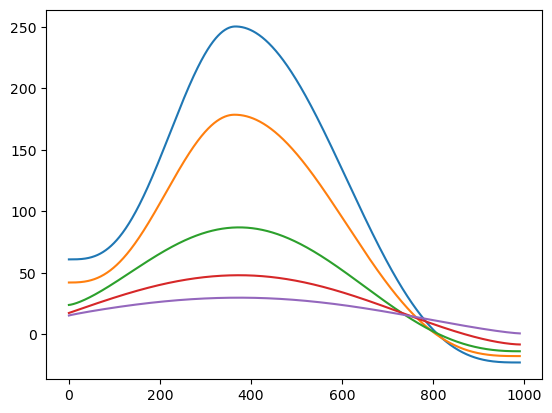

In [66]:
plt.plot(urad_new_2d[180,:])
plt.plot(urad_new_2d[150,:])
plt.plot(urad_new_2d[110,:])
plt.plot(urad_new_2d[80,:])
plt.plot(urad_new_2d[50,:])

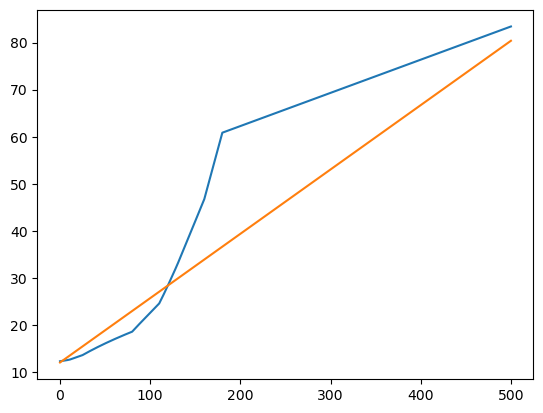

In [75]:
plt.plot(urad_new_2d[:,10])
plt.plot(urad_hm_2d[:,10])

k_ref = 110, z_ref = 31.96 km
urad_clim shape = (501, 992)
fit info for k=110
  t_peak_fit = 374 (93.50 days)
  u_min      = 23.808
  u_peak     = 86.864
  u_end      = -13.868
  p_pre      = 1.400
  p_post     = 2.400
  mse        = 8.486464
shear_t min/max = 0.5 3.6
urad_new_2d shape = (501, 992)
urad_new_3d shape = (501, 42, 992)
new urad min/max = -27.864929254355598 365.3837220907045


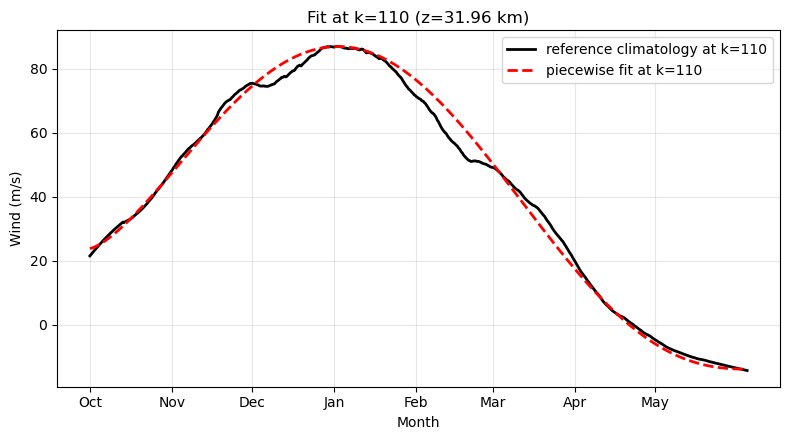

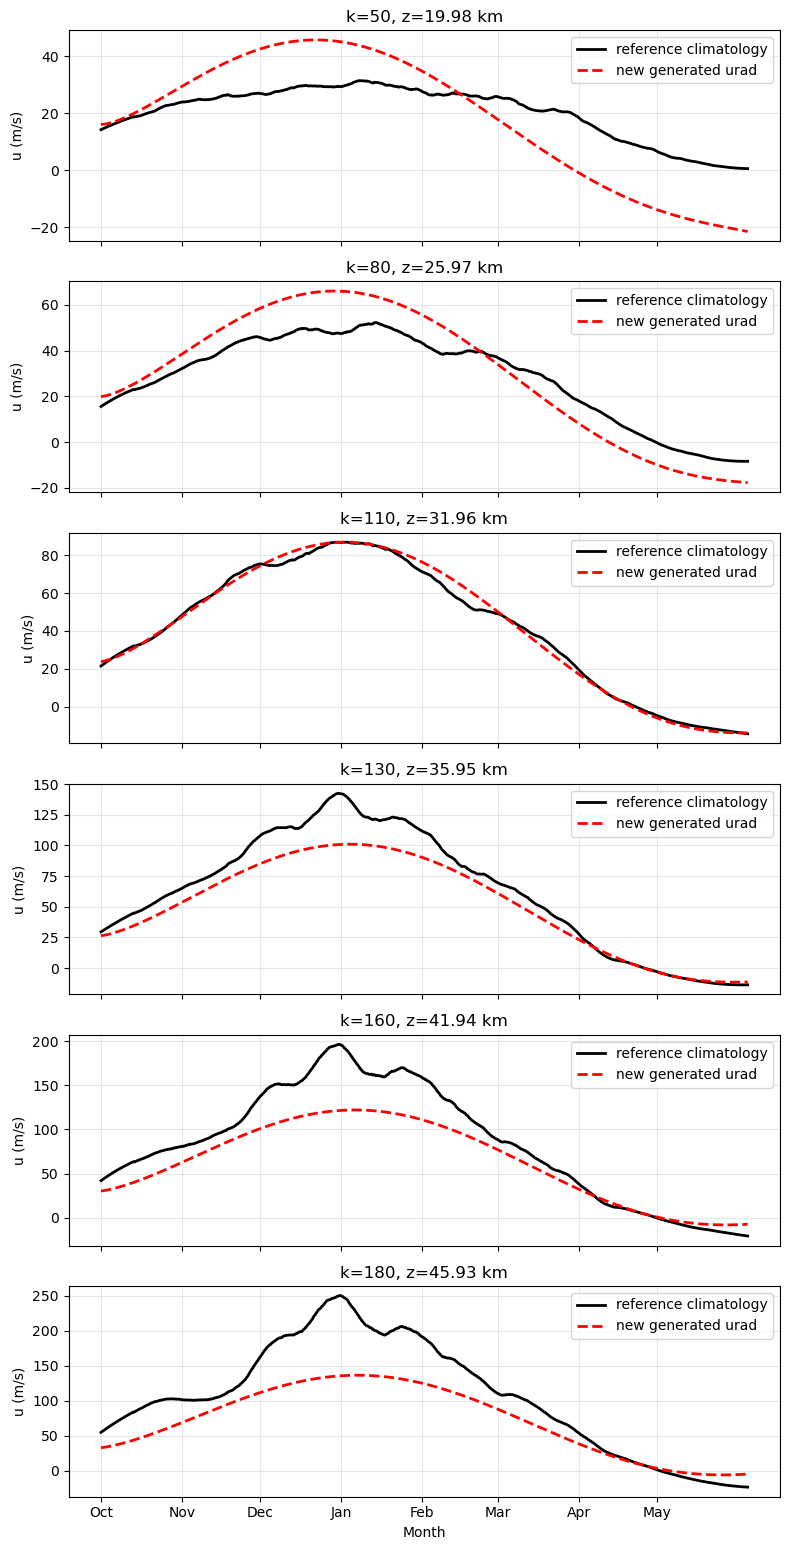

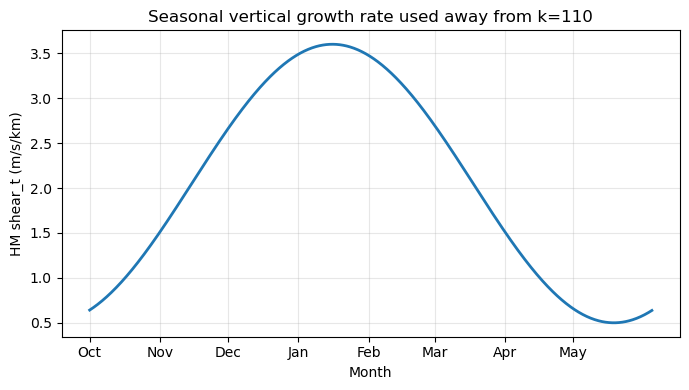

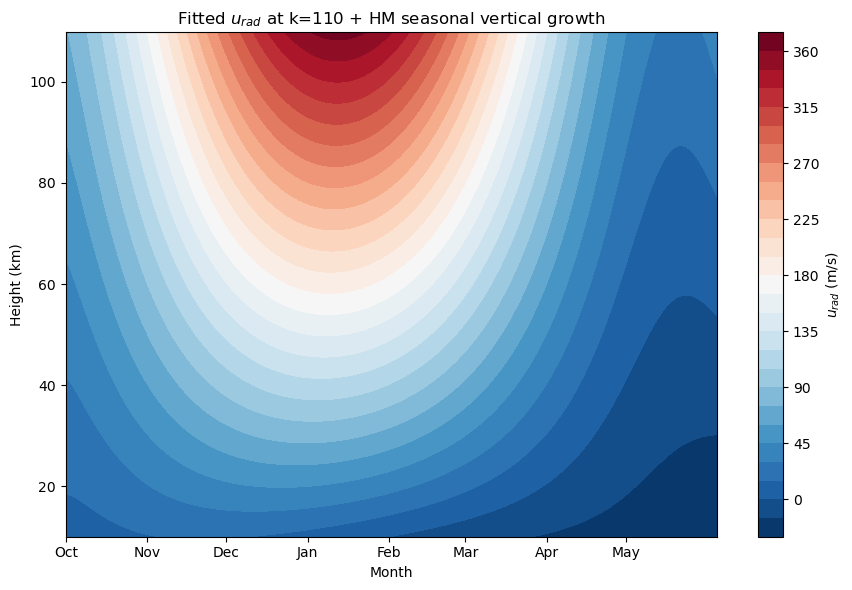

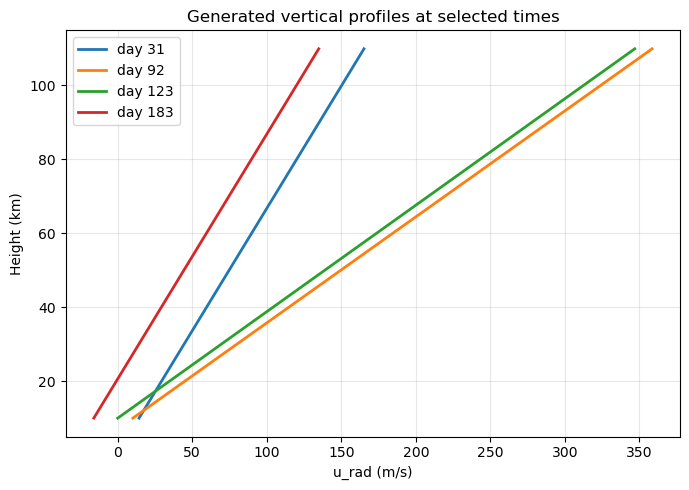

saved to: /mnt/winds/home/smliu01/0.1dmodel_2025/urad/urad_fit110_plus_HMshear_501_42.nc


In [76]:
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc

# =========================================================
# user settings
# =========================================================
nyear = 42
zdim  = 501
ntime = 992   # Oct-May, 6-hourly

ref_file = f'/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/urad_{zdim}.nc'
out_file = f'/mnt/winds/home/smliu01/0.1dmodel_2025/urad/urad_fit110_plus_HMshear_{zdim}_{nyear}.nc'

# fitted reference layer
k_ref = 110

# HM-style seasonal shear settings
u10 = 12.0
shear_min = 0.5
shear_max = 3.6

# optional scale factor on HM shear
# =1 means use HM shear directly
# <1 weakens vertical growth away from k=110
# >1 strengthens it
shear_scale = 1.0

# peak around mid-January for HM shear phase
t_peak_hm = 107 * 4

# if True, use actual argmax time from reference k=110 as fitting peak
# if False, force the fit peak at t_peak_hm
use_ref_peak_for_fit = True

# =========================================================
# helper
# =========================================================
def piecewise_shape(t, t_peak, u_min, u_peak, u_end, p_pre, p_post, ntime):
    """
    piecewise asymmetric seasonal curve:
      before peak : rises from u_min to u_peak
      after peak  : decays from u_peak to u_end
    """
    t = np.asarray(t, dtype=float)
    y = np.zeros_like(t, dtype=float)

    # before peak
    m1 = t <= t_peak
    if np.any(m1):
        x1 = np.zeros_like(t[m1], dtype=float)
        if t_peak > 0:
            x1 = t[m1] / t_peak
        x1 = np.clip(x1, 0.0, 1.0)
        y[m1] = u_min + (u_peak - u_min) * np.sin(0.5 * np.pi * x1) ** p_pre

    # after peak
    m2 = t > t_peak
    if np.any(m2):
        denom = (ntime - 1 - t_peak)
        x2 = np.zeros_like(t[m2], dtype=float)
        if denom > 0:
            x2 = (ntime - 1 - t[m2]) / denom
        x2 = np.clip(x2, 0.0, 1.0)
        y[m2] = u_end + (u_peak - u_end) * np.sin(0.5 * np.pi * x2) ** p_post

    return y

def fit_piecewise_given_peak(y, t_peak, ntime, p_candidates=None):
    """
    Fit one layer y(t) using piecewise asymmetric curve with fixed t_peak.
    """
    if p_candidates is None:
        p_candidates = np.arange(0.6, 3.01, 0.1)

    t = np.arange(len(y))
    y = np.asarray(y, dtype=float)

    u_peak = y[t_peak]
    u_min  = np.nanmean(y[:20])    # early Oct mean
    u_end  = np.nanmean(y[-20:])   # late May mean

    best = None
    best_err = np.inf

    for p_pre in p_candidates:
        for p_post in p_candidates:
            yfit = piecewise_shape(
                t=t,
                t_peak=t_peak,
                u_min=u_min,
                u_peak=u_peak,
                u_end=u_end,
                p_pre=p_pre,
                p_post=p_post,
                ntime=ntime
            )
            err = np.nanmean((y - yfit) ** 2)
            if err < best_err:
                best_err = err
                best = (u_min, u_peak, u_end, p_pre, p_post, yfit)

    return best, best_err

# =========================================================
# vertical grid
# =========================================================
hhh = np.arange(zdim) * (100.0 / zdim) + 10.0   # km
z_ref = hhh[k_ref]

print(f"k_ref = {k_ref}, z_ref = {z_ref:.2f} km")

# =========================================================
# time axis
# =========================================================
t_idx = np.arange(ntime)
t_days = t_idx / 4.0

# =========================================================
# load reference urad and compute climatology
# =========================================================
ds = nc.Dataset(ref_file, 'r')
urad_ref = np.array(ds.variables['urad'][:], dtype=float)
ds.close()

# climatology over years: (z, time)
urad_clim = np.nanmean(urad_ref, axis=1)

print("urad_clim shape =", urad_clim.shape)

# =========================================================
# fit only k=110 layer
# =========================================================
y_ref = urad_clim[k_ref, :]

if use_ref_peak_for_fit:
    t_peak_fit = int(np.nanargmax(y_ref))
else:
    t_peak_fit = t_peak_hm

best, fit_err = fit_piecewise_given_peak(y_ref, t_peak_fit, ntime=ntime)
u_min_110, u_peak_110, u_end_110, p_pre_110, p_post_110, yfit_110 = best

print("fit info for k=110")
print(f"  t_peak_fit = {t_peak_fit} ({t_peak_fit/4.0:.2f} days)")
print(f"  u_min      = {u_min_110:.3f}")
print(f"  u_peak     = {u_peak_110:.3f}")
print(f"  u_end      = {u_end_110:.3f}")
print(f"  p_pre      = {p_pre_110:.3f}")
print(f"  p_post     = {p_post_110:.3f}")
print(f"  mse        = {fit_err:.6f}")

# =========================================================
# HM-style seasonal shear_t
# =========================================================
phase = np.cos(2.0 * np.pi * (t_idx - t_peak_hm) / ntime)
phase01 = 0.5 * (phase + 1.0)
shear_t = shear_min + (shear_max - shear_min) * phase01
shear_t = shear_scale * shear_t

print("shear_t min/max =", shear_t.min(), shear_t.max())

# =========================================================
# generate urad(z,t):
# fitted 110-layer + HM seasonal vertical growth
# =========================================================
urad_new_2d = np.zeros((zdim, ntime), dtype=float)

for it in range(ntime):
    urad_new_2d[:, it] = yfit_110[it] + shear_t[it] * (hhh - z_ref)

# =========================================================
# expand to (zdim, nyear, ntime)
# =========================================================
urad_new_3d = np.repeat(urad_new_2d[:, np.newaxis, :], nyear, axis=1)

print("urad_new_2d shape =", urad_new_2d.shape)
print("urad_new_3d shape =", urad_new_3d.shape)
print("new urad min/max =", np.nanmin(urad_new_3d), np.nanmax(urad_new_3d))

# =========================================================
# compare 110-layer reference vs fit
# =========================================================
month_ticks = [0, 31, 61, 92, 123, 152, 183, 213]
month_labels = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May']

plt.figure(figsize=(8, 4.5))
plt.plot(t_days, y_ref, color='k', lw=2, label='reference climatology at k=110')
plt.plot(t_days, yfit_110, color='red', lw=2, ls='--', label='piecewise fit at k=110')
plt.xticks(month_ticks, month_labels)
plt.xlabel('Month')
plt.ylabel('Wind (m/s)')
plt.title(f'Fit at k={k_ref} (z={z_ref:.2f} km)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# compare several levels
# =========================================================
levels_to_plot = [50, 80, 110, 130, 160, 180]
fig, axes = plt.subplots(len(levels_to_plot), 1, figsize=(8, 2.6*len(levels_to_plot)), sharex=True)

if len(levels_to_plot) == 1:
    axes = [axes]

for ax, k in zip(axes, levels_to_plot):
    ax.plot(t_days, urad_clim[k, :], color='k', lw=2, label='reference climatology')
    ax.plot(t_days, urad_new_2d[k, :], color='red', lw=2, ls='--', label='new generated urad')
    ax.set_ylabel('u (m/s)')
    ax.set_title(f'k={k}, z={hhh[k]:.2f} km')
    ax.grid(alpha=0.3)
    ax.legend()

axes[-1].set_xticks(month_ticks)
axes[-1].set_xticklabels(month_labels)
axes[-1].set_xlabel('Month')

plt.tight_layout()
plt.show()

# =========================================================
# plot HM shear_t
# =========================================================
plt.figure(figsize=(7, 4))
plt.plot(t_days, shear_t, lw=2)
plt.xticks(month_ticks, month_labels)
plt.xlabel('Month')
plt.ylabel('HM shear_t (m/s/km)')
plt.title('Seasonal vertical growth rate used away from k=110')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# t-z contour
# =========================================================
T, Z = np.meshgrid(t_days, hhh)

plt.figure(figsize=(9, 6))
cf = plt.contourf(T, Z, urad_new_2d, levels=31, cmap='RdBu_r')
plt.colorbar(cf, label=r'$u_{rad}$ (m/s)')
plt.xticks(month_ticks, month_labels)
plt.xlabel('Month')
plt.ylabel('Height (km)')
plt.title(r'Fitted $u_{rad}$ at k=110 + HM seasonal vertical growth')
plt.tight_layout()
plt.show()

# =========================================================
# plot vertical profile at a few dates
# =========================================================
days_to_check = [31, 92, 123, 183]  # roughly Nov, Dec/Jan, Feb, Apr/May

plt.figure(figsize=(7, 5))
for dd in days_to_check:
    it = int(dd * 4)
    plt.plot(urad_new_2d[:, it], hhh, lw=2, label=f'day {dd}')
plt.xlabel('u_rad (m/s)')
plt.ylabel('Height (km)')
plt.title('Generated vertical profiles at selected times')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# save to netCDF
# =========================================================
ncfile = nc.Dataset(out_file, mode='w', format='NETCDF4')

# dimensions
ncfile.createDimension('height', zdim)
ncfile.createDimension('year', nyear)
ncfile.createDimension('time', ntime)

# coordinate variables
height_var = ncfile.createVariable('height', np.float32, ('height',))
year_var   = ncfile.createVariable('year', np.int32, ('year',))
time_var   = ncfile.createVariable('time', np.int32, ('time',))

# main variable
urad_var = ncfile.createVariable('urad', np.float32, ('height', 'year', 'time'))

# write coordinates
height_var[:] = hhh
year_var[:]   = np.arange(nyear)
time_var[:]   = np.arange(ntime)

# attributes
height_var.units = 'km'
height_var.long_name = 'height'
year_var.long_name = 'year index'
time_var.long_name = '6-hourly time index from Oct 1'
urad_var.units = 'm s-1'
urad_var.long_name = 'urad generated from fitted k=110 seasonal cycle plus HM seasonal vertical growth'

# write data
urad_var[:] = urad_new_3d.astype(np.float32)

ncfile.close()

print("saved to:", out_file)

Requested z_cut = 32.00 km
Actual nearest grid point: k_cut = 110, z_cut_actual = 31.956 km
urad_clim shape = (501, 992)
common lower t_peak = 374 day = 93.5
LOW k= 50, z= 19.98 km, t_peak= 374, u_min=  15.207, u_peak=  29.708, u_end=   0.650, p_pre= 0.90, p_post= 1.30, mse=   1.4470
LOW k= 80, z= 25.97 km, t_peak= 374, u_min=  17.261, u_peak=  47.956, u_end=  -8.346, p_pre= 1.00, p_post= 1.60, mse=   4.3465
LOW k=110, z= 31.96 km, t_peak= 374, u_min=  23.808, u_peak=  86.864, u_end= -13.868, p_pre= 1.40, p_post= 2.40, mse=   8.4865
shear_t min/max = 0.5 3.6
urad_new_2d shape = (501, 992)
urad_new_3d shape = (501, 42, 992)
new urad min/max = -13.868218183517456 367.1033133775174


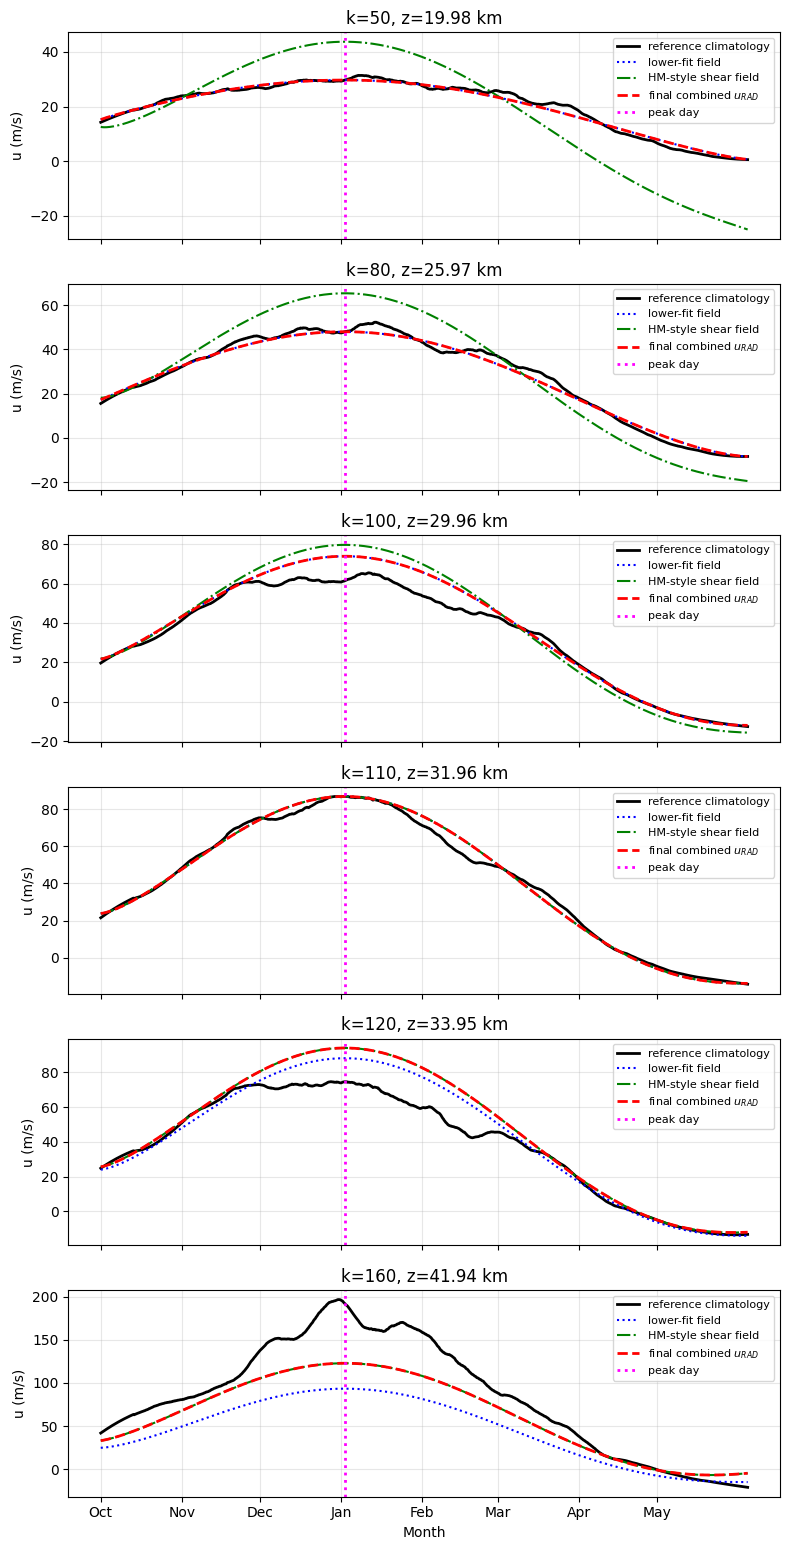

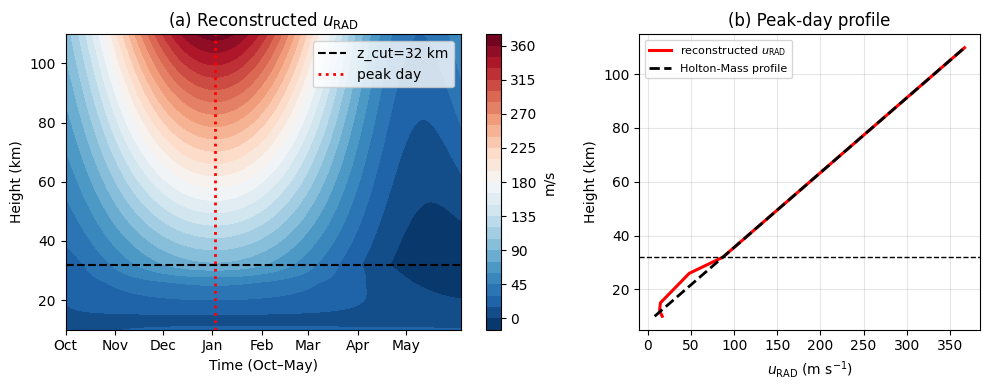

In [1]:
### plot only

import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc

# =========================================================
# user settings
# =========================================================
nyear = 42
zdim  = 501
ntime = 992

ref_file = f'/nas/winds-home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/urad_{zdim}.nc'
out_file = f'/nas/winds-home/smliu01/0.1dmodel_2025/urad/urad_below32_fit_above32_HMshear_{zdim}_{nyear}.nc'

# =========================================================
# lower-part fitting settings
# IMPORTANT: only use anchors BELOW / AT 32 km
# =========================================================
k_ref = 110
lower_anchors = [50, 80, 110]
use_common_peak = True
right_slope_factor_low = 0.1
npass_smooth_low = 0

# =========================================================
# HM-style shear settings for above 32 km
# =========================================================
shear_min = 0.5
shear_max = 3.6
shear_scale = 1.0

# Peak day: Jan 2 is about 93.5 days after Oct 1
peak_day = 93.5
t_peak_hm = int(round(peak_day * 4))

# =========================================================
# transition height
# =========================================================
z_cut = 32.0   # km
blend_half_width_km = 0.0   # set 0 for hard switch

# =========================================================
# helper
# =========================================================
def smooth121_1d(x, npass=3):
    x = np.asarray(x, dtype=float).copy()
    if npass <= 0:
        return x
    for _ in range(npass):
        y = x.copy()
        for i in range(1, len(x)-1):
            vals = np.array([x[i-1], x[i], x[i+1]], dtype=float)
            w = np.array([1.0, 2.0, 1.0], dtype=float)
            m = np.isfinite(vals)
            if np.any(m):
                y[i] = np.sum(vals[m] * w[m]) / np.sum(w[m])
        x = y
    return x


def piecewise_shape(t, t_peak, u_min, u_peak, u_end, p_pre, p_post, ntime):
    t = np.asarray(t, dtype=float)
    y = np.zeros_like(t, dtype=float)

    # before peak
    m1 = t <= t_peak
    if np.any(m1):
        x1 = np.zeros_like(t[m1], dtype=float)
        if t_peak > 0:
            x1 = t[m1] / t_peak
        x1 = np.clip(x1, 0.0, 1.0)
        y[m1] = u_min + (u_peak - u_min) * np.sin(0.5 * np.pi * x1) ** p_pre

    # after peak
    m2 = t > t_peak
    if np.any(m2):
        denom = (ntime - 1 - t_peak)
        x2 = np.zeros_like(t[m2], dtype=float)
        if denom > 0:
            x2 = (ntime - 1 - t[m2]) / denom
        x2 = np.clip(x2, 0.0, 1.0)
        y[m2] = u_end + (u_peak - u_end) * np.sin(0.5 * np.pi * x2) ** p_post

    return y


def fit_piecewise_given_peak(y, t_peak, ntime, p_candidates=None):
    if p_candidates is None:
        p_candidates = np.arange(0.6, 3.01, 0.1)

    t = np.arange(len(y))
    y = np.asarray(y, dtype=float)

    u_peak = y[t_peak]
    u_min  = np.nanmean(y[:20])
    u_end  = np.nanmean(y[-20:])

    best = None
    best_err = np.inf

    for p_pre in p_candidates:
        for p_post in p_candidates:
            yfit = piecewise_shape(
                t=t,
                t_peak=t_peak,
                u_min=u_min,
                u_peak=u_peak,
                u_end=u_end,
                p_pre=p_pre,
                p_post=p_post,
                ntime=ntime
            )
            err = np.nanmean((y - yfit) ** 2)
            if err < best_err:
                best_err = err
                best = (u_min, u_peak, u_end, p_pre, p_post, yfit)

    return best, best_err


def interp_piecewise_linear_scaled_right(x_new, x, y, right_slope_factor=0.35):
    x_new = np.asarray(x_new, dtype=float)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    y_new = np.empty_like(x_new, dtype=float)

    # left extrapolation
    slope_left = (y[1] - y[0]) / (x[1] - x[0])
    m_left = x_new <= x[0]
    y_new[m_left] = y[0] + slope_left * (x_new[m_left] - x[0])

    # piecewise linear interpolation inside
    for i in range(len(x) - 1):
        m = (x_new > x[i]) & (x_new <= x[i+1])
        frac = (x_new[m] - x[i]) / (x[i+1] - x[i])
        y_new[m] = y[i] + frac * (y[i+1] - y[i])

    # exact first anchor
    y_new[x_new == x[0]] = y[0]

    # right extrapolation
    slope_right = (y[-1] - y[-2]) / (x[-1] - x[-2])
    slope_right_scaled = right_slope_factor * slope_right
    m_right = x_new > x[-1]
    y_new[m_right] = y[-1] + slope_right_scaled * (x_new[m_right] - x[-1])

    return y_new


# =========================================================
# vertical grid
# =========================================================
hhh = np.arange(zdim) * (100.0 / zdim) + 10.0   # km
k_all = np.arange(zdim, dtype=float)

k_cut = int(np.argmin(np.abs(hhh - z_cut)))
z_cut_actual = hhh[k_cut]

print(f"Requested z_cut = {z_cut:.2f} km")
print(f"Actual nearest grid point: k_cut = {k_cut}, z_cut_actual = {z_cut_actual:.3f} km")

# =========================================================
# time axis
# =========================================================
t_idx = np.arange(ntime)
t_days = t_idx / 4.0
t = np.arange(ntime)

# =========================================================
# load reference
# =========================================================
ds = nc.Dataset(ref_file, 'r')
urad_ref = np.array(ds.variables['urad'][:], dtype=float)
ds.close()

urad_clim = np.nanmean(urad_ref, axis=1)
print("urad_clim shape =", urad_clim.shape)

# =========================================================
# fit ONLY lower anchors [50,80,110]
# =========================================================
t_peak_common = int(np.nanargmax(urad_clim[k_ref, :])) if use_common_peak else None
print("common lower t_peak =", t_peak_common, "day =", t_peak_common/4.0 if t_peak_common is not None else None)

lower_anchor_params = {}

for k in lower_anchors:
    y = urad_clim[k, :]

    if use_common_peak:
        tpk = t_peak_common
    else:
        tpk = int(np.nanargmax(y))

    best, err = fit_piecewise_given_peak(y, tpk, ntime=ntime)
    u_min, u_peak, u_end, p_pre, p_post, yfit = best

    lower_anchor_params[k] = {
        't_peak': tpk,
        'u_min': u_min,
        'u_peak': u_peak,
        'u_end': u_end,
        'p_pre': p_pre,
        'p_post': p_post,
        'fit': yfit,
        'mse': err
    }

    print(
        f"LOW k={k:3d}, z={hhh[k]:6.2f} km, "
        f"t_peak={tpk:4d}, "
        f"u_min={u_min:8.3f}, u_peak={u_peak:8.3f}, u_end={u_end:8.3f}, "
        f"p_pre={p_pre:5.2f}, p_post={p_post:5.2f}, mse={err:9.4f}"
    )

# =========================================================
# build lower fitted field using ONLY lower anchors
# =========================================================
k_anchor_low = np.array(lower_anchors, dtype=float)

u_min_anchor_low  = np.array([lower_anchor_params[k]['u_min']  for k in lower_anchors], dtype=float)
u_peak_anchor_low = np.array([lower_anchor_params[k]['u_peak'] for k in lower_anchors], dtype=float)
u_end_anchor_low  = np.array([lower_anchor_params[k]['u_end']  for k in lower_anchors], dtype=float)
p_pre_anchor_low  = np.array([lower_anchor_params[k]['p_pre']  for k in lower_anchors], dtype=float)
p_post_anchor_low = np.array([lower_anchor_params[k]['p_post'] for k in lower_anchors], dtype=float)
t_peak_anchor_low = np.array([lower_anchor_params[k]['t_peak'] for k in lower_anchors], dtype=float)

u_min_prof_low  = interp_piecewise_linear_scaled_right(
    k_all, k_anchor_low, u_min_anchor_low, right_slope_factor=right_slope_factor_low
)
u_peak_prof_low = interp_piecewise_linear_scaled_right(
    k_all, k_anchor_low, u_peak_anchor_low, right_slope_factor=right_slope_factor_low
)
u_end_prof_low  = interp_piecewise_linear_scaled_right(
    k_all, k_anchor_low, u_end_anchor_low, right_slope_factor=right_slope_factor_low
)
p_pre_prof_low  = interp_piecewise_linear_scaled_right(
    k_all, k_anchor_low, p_pre_anchor_low, right_slope_factor=right_slope_factor_low
)
p_post_prof_low = interp_piecewise_linear_scaled_right(
    k_all, k_anchor_low, p_post_anchor_low, right_slope_factor=right_slope_factor_low
)
t_peak_prof_low = interp_piecewise_linear_scaled_right(
    k_all, k_anchor_low, t_peak_anchor_low, right_slope_factor=0.0
)

u_min_prof_low  = smooth121_1d(u_min_prof_low,  npass=npass_smooth_low)
u_peak_prof_low = smooth121_1d(u_peak_prof_low, npass=npass_smooth_low)
u_end_prof_low  = smooth121_1d(u_end_prof_low,  npass=npass_smooth_low)
p_pre_prof_low  = smooth121_1d(p_pre_prof_low,  npass=npass_smooth_low)
p_post_prof_low = smooth121_1d(p_post_prof_low, npass=npass_smooth_low)

u_peak_prof_low = np.maximum(u_peak_prof_low, u_min_prof_low + 1.0)
u_peak_prof_low = np.maximum(u_peak_prof_low, u_end_prof_low + 1.0)

urad_fit_low_2d = np.zeros((zdim, ntime), dtype=float)

for k in range(zdim):
    tpk_use = int(np.round(t_peak_prof_low[k]))
    tpk_use = max(1, min(ntime - 2, tpk_use))

    urad_fit_low_2d[k, :] = piecewise_shape(
        t=t,
        t_peak=tpk_use,
        u_min=u_min_prof_low[k],
        u_peak=u_peak_prof_low[k],
        u_end=u_end_prof_low[k],
        p_pre=p_pre_prof_low[k],
        p_post=p_post_prof_low[k],
        ntime=ntime
    )

# =========================================================
# HM seasonal shear for ABOVE 32 km, anchored at z_cut
# =========================================================
phase = np.cos(2.0 * np.pi * (t_idx - t_peak_hm) / ntime)
phase01 = 0.5 * (phase + 1.0)
shear_t = shear_min + (shear_max - shear_min) * phase01
shear_t = shear_scale * shear_t

print("shear_t min/max =", shear_t.min(), shear_t.max())

urad_hm_above_2d = np.zeros((zdim, ntime), dtype=float)
for it in range(ntime):
    urad_hm_above_2d[:, it] = (
        urad_fit_low_2d[k_cut, it]
        + shear_t[it] * (hhh - z_cut_actual)
    )

# =========================================================
# final combine
# =========================================================
urad_new_2d = np.zeros((zdim, ntime), dtype=float)

if blend_half_width_km <= 0.0:
    mask_low = hhh <= z_cut_actual
    mask_high = hhh > z_cut_actual
    urad_new_2d[mask_low, :] = urad_fit_low_2d[mask_low, :]
    urad_new_2d[mask_high, :] = urad_hm_above_2d[mask_high, :]
else:
    z1 = z_cut_actual - blend_half_width_km
    z2 = z_cut_actual + blend_half_width_km
    for k in range(zdim):
        z = hhh[k]
        if z <= z1:
            urad_new_2d[k, :] = urad_fit_low_2d[k, :]
        elif z >= z2:
            urad_new_2d[k, :] = urad_hm_above_2d[k, :]
        else:
            w = (z - z1) / (z2 - z1)
            urad_new_2d[k, :] = (
                (1.0 - w) * urad_fit_low_2d[k, :]
                + w * urad_hm_above_2d[k, :]
            )

# =========================================================
# expand to all years
# =========================================================
urad_new_3d = np.repeat(urad_new_2d[:, np.newaxis, :], nyear, axis=1)

print("urad_new_2d shape =", urad_new_2d.shape)
print("urad_new_3d shape =", urad_new_3d.shape)
print("new urad min/max =", np.nanmin(urad_new_3d), np.nanmax(urad_new_3d))

# =========================================================
# diagnostic line plots
# =========================================================
month_ticks = [0, 31, 61, 92, 123, 152, 183, 213]
month_labels = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May']

levels_to_plot = [50, 80, 100, k_cut, 120, 160]
fig, axes = plt.subplots(
    len(levels_to_plot), 1,
    figsize=(8, 2.6 * len(levels_to_plot)),
    sharex=True
)

if len(levels_to_plot) == 1:
    axes = [axes]

for ax, k in zip(axes, levels_to_plot):
    ax.plot(t_days, urad_clim[k, :], color='k', lw=2, label='reference climatology')
    ax.plot(t_days, urad_fit_low_2d[k, :], color='blue', lw=1.5, ls=':', label='lower-fit field')
    ax.plot(t_days, urad_hm_above_2d[k, :], color='green', lw=1.5, ls='-.', label='HM-style shear field')
    ax.plot(t_days, urad_new_2d[k, :], color='red', lw=2, ls='--', label='final combined $u_{RAD}$')

    ax.axvline(peak_day, color='magenta', ls=':', lw=2, label='peak day')

    ax.set_ylabel('u (m/s)')
    ax.set_title(f'k={k}, z={hhh[k]:.2f} km')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

axes[-1].set_xticks(month_ticks)
axes[-1].set_xticklabels(month_labels)
axes[-1].set_xlabel('Month')

plt.tight_layout()
plt.show()

# =========================================================
# final figure:
# (a) original time-height contour
# (b) peak-day vertical profile comparison
# =========================================================

T, Z = np.meshgrid(t_days, hhh)

peak_day = 93.5
peak_idx = int(round(peak_day * 4))
peak_idx = max(0, min(ntime - 1, peak_idx))
peak_day_plot = t_days[peak_idx]

urad_peak_profile = urad_new_2d[:, peak_idx]
hm_peak_profile = urad_hm_above_2d[:, peak_idx]
ref_peak_profile = urad_clim[:, peak_idx]

fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 4),
    gridspec_kw={'width_ratios': [1.45, 1.0]}
)

# -------------------------
# (a)  t-z contour colorbar
# -------------------------
ax = axes[0]

cf = ax.contourf(T, Z, urad_new_2d, levels=31, cmap='RdBu_r')
fig.colorbar(cf, ax=ax, label=r'm/s')

ax.axhline(
    z_cut_actual,
    color='k',
    ls='--',
    lw=1.5,
    label=f'z_cut=32 km'
)

ax.axvline(
    peak_day,
    color='red',
    ls=':',
    lw=2,
    label='peak day'
)

ax.set_xticks(month_ticks)
ax.set_xticklabels(month_labels)
ax.set_xlabel('Time (Oct–May)')
ax.set_ylabel('Height (km)')
ax.set_title(r'(a) Reconstructed $u_{\mathrm{RAD}}$')
ax.legend()

# -------------------------
# (b) peak-day vertical profile comparison
# -------------------------
ax = axes[1]

ax.plot(
    urad_peak_profile,
    hhh,
    color='red',
    lw=2.2,
    label=r'reconstructed $u_{\mathrm{RAD}}$'
)

ax.plot(
    hm_peak_profile,
    hhh,
    color='k',
    lw=2.0,
    ls='--',
    label='Holton-Mass profile'
)

# ax.plot(
#     ref_peak_profile,
#     hhh,
#     color='gray',
#     lw=1.6,
#     ls=':',
#     label='ERA5-diagnosed reference'
# )

ax.axhline(
    z_cut_actual,
    color='k',
    ls='--',
    lw=1.0
)

ax.set_xlabel(r'$u_{\mathrm{RAD}}$ (m s$^{-1}$)')
ax.set_ylabel('Height (km)')
ax.set_title('(b) Peak-day profile')
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("urad_hm_with_profile.png", bbox_inches="tight", dpi=600)
plt.show()

In [ ]:
# =========================================================
# save to netCDF
# =========================================================
ncfile = nc.Dataset(out_file, mode='w', format='NETCDF4')

ncfile.createDimension('height', zdim)
ncfile.createDimension('year', nyear)
ncfile.createDimension('time', ntime)

height_var = ncfile.createVariable('height', np.float32, ('height',))
year_var   = ncfile.createVariable('year', np.int32, ('year',))
time_var   = ncfile.createVariable('time', np.int32, ('time',))
urad_var   = ncfile.createVariable('urad', np.float32, ('height', 'year', 'time'))

height_var[:] = hhh
year_var[:]   = np.arange(nyear)
time_var[:]   = np.arange(ntime)
urad_var[:]   = urad_new_3d.astype(np.float32)

height_var.units = 'km'
height_var.long_name = 'height'
year_var.long_name = 'year index'
time_var.long_name = '6-hourly time index from Oct 1'
urad_var.units = 'm s-1'
urad_var.long_name = 'combined urad: below 32 km lower-anchor fit only, above 32 km HM shear'

ncfile.close()

print("saved to:", out_file)

uRAD phase advanced by 10.0 days: old peak day=93.5, new peak day=93.5
Extra boost starts above 5.0 hPa: z_boost = 37.09 km
extra_shear_above_5hpa = 1.200 m/s/km
Requested z_cut = 32.00 km
Actual nearest grid point: k_cut = 110, z_cut_actual = 31.956 km
Requested z_boost = 37.09 km
Actual nearest grid point: k_boost = 136, z_boost_actual = 37.146 km
urad_clim shape = (501, 992)
common lower t_peak raw = 374 day = 93.5
LOW k= 50, z= 19.98 km, t_peak_raw= 374, u_min=  15.207, u_peak=  29.708, u_end=   0.650, p_pre= 0.90, p_post= 1.30, mse=   1.4470
LOW k= 80, z= 25.97 km, t_peak_raw= 374, u_min=  17.261, u_peak=  47.956, u_end=  -8.346, p_pre= 1.00, p_post= 1.60, mse=   4.3465
LOW k=110, z= 31.96 km, t_peak_raw= 374, u_min=  23.808, u_peak=  86.864, u_end= -13.868, p_pre= 1.40, p_post= 2.40, mse=   8.4865
raw lower peak days     = [93.5 93.5 93.5]
shifted lower peak days = [83.5 83.5 83.5]
shear_t min/max = 0.5 3.6
extra_shear_t min/max = 0.0 1.2
extra boost max = 87.18562874251496
new u

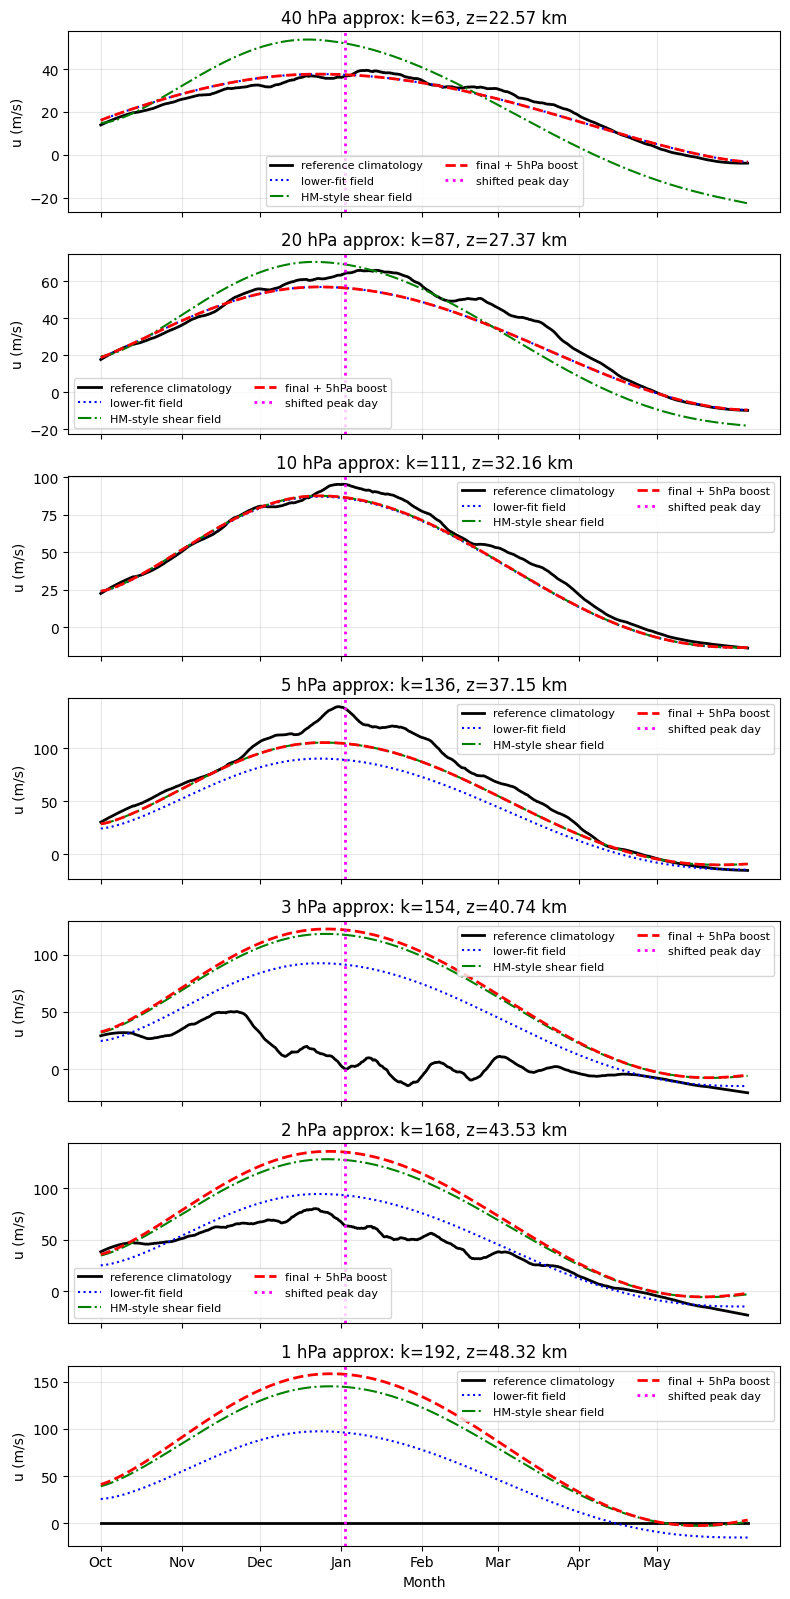

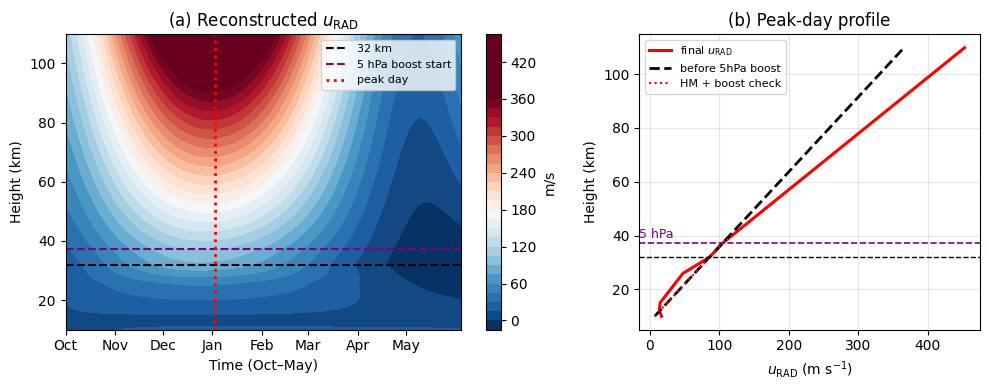

In [10]:
### urad with 10-day phase advance + extra increasing boost above 5 hPa

import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc
import os

# =========================================================
# user settings
# =========================================================
nyear = 42
zdim  = 501
ntime = 992

ref_file = f'/nas/winds-home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/urad_{zdim}.nc'

out_file = (
    f'/nas/winds-home/smliu01/0.1dmodel_2025/urad/'
    f'urad_below32_fit_above32_HMshear_{zdim}_{nyear}_early.nc'
)

# =========================================================
# lower-part fitting settings
# IMPORTANT: only use anchors BELOW / AT 32 km
# =========================================================
k_ref = 110
lower_anchors = [50, 80, 110]
use_common_peak = True
right_slope_factor_low = 0.1
npass_smooth_low = 0

# =========================================================
# HM-style shear settings for above 32 km
# =========================================================
shear_min = 0.5
shear_max = 3.6
shear_scale = 1.0

# =========================================================
# phase shift suggested by Noboru
# =========================================================
peak_day_old = 93.5          # original peak: about Jan 2
phase_advance_days = 10.0    # shift u_RAD peak earlier by 10 days

peak_day = 93.5 #peak_day_old - phase_advance_days   # about Dec 23
phase_advance_steps = int(round(phase_advance_days * 4))
t_peak_hm = int(round(peak_day * 4))

print(
    f"uRAD phase advanced by {phase_advance_days:.1f} days: "
    f"old peak day={peak_day_old:.1f}, new peak day={peak_day:.1f}"
)

# =========================================================
# extra boost above 5 hPa
# =========================================================
p0_hpa = 1000.0
H_km = 7.0

boost_above_p = 5.0
z_boost = H_km * np.log(p0_hpa / boost_above_p)  # about 37.1 km

# 
#  m/s/km 5 hPa 
#  0.8 1.0  1.2
extra_shear_above_5hpa = 1.2

#  extra boost 
# True: 
# False:  ramp
use_seasonal_extra_boost = True

print(f"Extra boost starts above {boost_above_p:.1f} hPa: z_boost = {z_boost:.2f} km")
print(f"extra_shear_above_5hpa = {extra_shear_above_5hpa:.3f} m/s/km")

# =========================================================
# transition height
# =========================================================
z_cut = 32.0   # km
blend_half_width_km = 0.0   # set 0 for hard switch

# =========================================================
# helper
# =========================================================
def smooth121_1d(x, npass=3):
    x = np.asarray(x, dtype=float).copy()
    if npass <= 0:
        return x
    for _ in range(npass):
        y = x.copy()
        for i in range(1, len(x)-1):
            vals = np.array([x[i-1], x[i], x[i+1]], dtype=float)
            w = np.array([1.0, 2.0, 1.0], dtype=float)
            m = np.isfinite(vals)
            if np.any(m):
                y[i] = np.sum(vals[m] * w[m]) / np.sum(w[m])
        x = y
    return x


def piecewise_shape(t, t_peak, u_min, u_peak, u_end, p_pre, p_post, ntime):
    t = np.asarray(t, dtype=float)
    y = np.zeros_like(t, dtype=float)

    # before peak
    m1 = t <= t_peak
    if np.any(m1):
        x1 = np.zeros_like(t[m1], dtype=float)
        if t_peak > 0:
            x1 = t[m1] / t_peak
        x1 = np.clip(x1, 0.0, 1.0)
        y[m1] = u_min + (u_peak - u_min) * np.sin(0.5 * np.pi * x1) ** p_pre

    # after peak
    m2 = t > t_peak
    if np.any(m2):
        denom = (ntime - 1 - t_peak)
        x2 = np.zeros_like(t[m2], dtype=float)
        if denom > 0:
            x2 = (ntime - 1 - t[m2]) / denom
        x2 = np.clip(x2, 0.0, 1.0)
        y[m2] = u_end + (u_peak - u_end) * np.sin(0.5 * np.pi * x2) ** p_post

    return y


def fit_piecewise_given_peak(y, t_peak, ntime, p_candidates=None):
    if p_candidates is None:
        p_candidates = np.arange(0.6, 3.01, 0.1)

    t = np.arange(len(y))
    y = np.asarray(y, dtype=float)

    u_peak = y[t_peak]
    u_min  = np.nanmean(y[:20])
    u_end  = np.nanmean(y[-20:])

    best = None
    best_err = np.inf

    for p_pre in p_candidates:
        for p_post in p_candidates:
            yfit = piecewise_shape(
                t=t,
                t_peak=t_peak,
                u_min=u_min,
                u_peak=u_peak,
                u_end=u_end,
                p_pre=p_pre,
                p_post=p_post,
                ntime=ntime
            )
            err = np.nanmean((y - yfit) ** 2)
            if err < best_err:
                best_err = err
                best = (u_min, u_peak, u_end, p_pre, p_post, yfit)

    return best, best_err


def interp_piecewise_linear_scaled_right(x_new, x, y, right_slope_factor=0.35):
    x_new = np.asarray(x_new, dtype=float)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    y_new = np.empty_like(x_new, dtype=float)

    # left extrapolation
    slope_left = (y[1] - y[0]) / (x[1] - x[0])
    m_left = x_new <= x[0]
    y_new[m_left] = y[0] + slope_left * (x_new[m_left] - x[0])

    # piecewise linear interpolation inside
    for i in range(len(x) - 1):
        m = (x_new > x[i]) & (x_new <= x[i+1])
        frac = (x_new[m] - x[i]) / (x[i+1] - x[i])
        y_new[m] = y[i] + frac * (y[i+1] - y[i])

    # exact first anchor
    y_new[x_new == x[0]] = y[0]

    # right extrapolation
    slope_right = (y[-1] - y[-2]) / (x[-1] - x[-2])
    slope_right_scaled = right_slope_factor * slope_right
    m_right = x_new > x[-1]
    y_new[m_right] = y[-1] + slope_right_scaled * (x_new[m_right] - x[-1])

    return y_new


def z_from_p(p_hpa, H_km=7.0, p0_hpa=1000.0):
    return H_km * np.log(p0_hpa / p_hpa)


# =========================================================
# vertical grid
# =========================================================
hhh = np.arange(zdim) * (100.0 / zdim) + 10.0   # km
k_all = np.arange(zdim, dtype=float)

k_cut = int(np.argmin(np.abs(hhh - z_cut)))
z_cut_actual = hhh[k_cut]

k_boost = int(np.argmin(np.abs(hhh - z_boost)))
z_boost_actual = hhh[k_boost]

print(f"Requested z_cut = {z_cut:.2f} km")
print(f"Actual nearest grid point: k_cut = {k_cut}, z_cut_actual = {z_cut_actual:.3f} km")
print(f"Requested z_boost = {z_boost:.2f} km")
print(f"Actual nearest grid point: k_boost = {k_boost}, z_boost_actual = {z_boost_actual:.3f} km")

# =========================================================
# time axis
# =========================================================
t_idx = np.arange(ntime)
t_days = t_idx / 4.0
t = np.arange(ntime)

# =========================================================
# load reference
# =========================================================
ds = nc.Dataset(ref_file, 'r')
urad_ref = np.array(ds.variables['urad'][:], dtype=float)
ds.close()

urad_clim = np.nanmean(urad_ref, axis=1)
print("urad_clim shape =", urad_clim.shape)

# =========================================================
# fit ONLY lower anchors [50,80,110]
# =========================================================
t_peak_common = int(np.nanargmax(urad_clim[k_ref, :])) if use_common_peak else None
print("common lower t_peak raw =", t_peak_common, "day =", t_peak_common/4.0 if t_peak_common is not None else None)

lower_anchor_params = {}

for k in lower_anchors:
    y = urad_clim[k, :]

    if use_common_peak:
        tpk = t_peak_common
    else:
        tpk = int(np.nanargmax(y))

    best, err = fit_piecewise_given_peak(y, tpk, ntime=ntime)
    u_min, u_peak, u_end, p_pre, p_post, yfit = best

    lower_anchor_params[k] = {
        't_peak': tpk,
        'u_min': u_min,
        'u_peak': u_peak,
        'u_end': u_end,
        'p_pre': p_pre,
        'p_post': p_post,
        'fit': yfit,
        'mse': err
    }

    print(
        f"LOW k={k:3d}, z={hhh[k]:6.2f} km, "
        f"t_peak_raw={tpk:4d}, "
        f"u_min={u_min:8.3f}, u_peak={u_peak:8.3f}, u_end={u_end:8.3f}, "
        f"p_pre={p_pre:5.2f}, p_post={p_post:5.2f}, mse={err:9.4f}"
    )

# =========================================================
# build lower fitted field using ONLY lower anchors
# =========================================================
k_anchor_low = np.array(lower_anchors, dtype=float)

u_min_anchor_low  = np.array([lower_anchor_params[k]['u_min']  for k in lower_anchors], dtype=float)
u_peak_anchor_low = np.array([lower_anchor_params[k]['u_peak'] for k in lower_anchors], dtype=float)
u_end_anchor_low  = np.array([lower_anchor_params[k]['u_end']  for k in lower_anchors], dtype=float)
p_pre_anchor_low  = np.array([lower_anchor_params[k]['p_pre']  for k in lower_anchors], dtype=float)
p_post_anchor_low = np.array([lower_anchor_params[k]['p_post'] for k in lower_anchors], dtype=float)

# raw lower peak
t_peak_anchor_low_raw = np.array(
    [lower_anchor_params[k]['t_peak'] for k in lower_anchors],
    dtype=float
)

# apply 10-day phase advance to lower fit too
t_peak_anchor_low = t_peak_anchor_low_raw - phase_advance_steps
t_peak_anchor_low = np.clip(t_peak_anchor_low, 1, ntime - 2)

print("raw lower peak days     =", t_peak_anchor_low_raw / 4.0)
print("shifted lower peak days =", t_peak_anchor_low / 4.0)

u_min_prof_low  = interp_piecewise_linear_scaled_right(
    k_all, k_anchor_low, u_min_anchor_low, right_slope_factor=right_slope_factor_low
)
u_peak_prof_low = interp_piecewise_linear_scaled_right(
    k_all, k_anchor_low, u_peak_anchor_low, right_slope_factor=right_slope_factor_low
)
u_end_prof_low  = interp_piecewise_linear_scaled_right(
    k_all, k_anchor_low, u_end_anchor_low, right_slope_factor=right_slope_factor_low
)
p_pre_prof_low  = interp_piecewise_linear_scaled_right(
    k_all, k_anchor_low, p_pre_anchor_low, right_slope_factor=right_slope_factor_low
)
p_post_prof_low = interp_piecewise_linear_scaled_right(
    k_all, k_anchor_low, p_post_anchor_low, right_slope_factor=right_slope_factor_low
)
t_peak_prof_low = interp_piecewise_linear_scaled_right(
    k_all, k_anchor_low, t_peak_anchor_low, right_slope_factor=0.0
)

u_min_prof_low  = smooth121_1d(u_min_prof_low,  npass=npass_smooth_low)
u_peak_prof_low = smooth121_1d(u_peak_prof_low, npass=npass_smooth_low)
u_end_prof_low  = smooth121_1d(u_end_prof_low,  npass=npass_smooth_low)
p_pre_prof_low  = smooth121_1d(p_pre_prof_low,  npass=npass_smooth_low)
p_post_prof_low = smooth121_1d(p_post_prof_low, npass=npass_smooth_low)

u_peak_prof_low = np.maximum(u_peak_prof_low, u_min_prof_low + 1.0)
u_peak_prof_low = np.maximum(u_peak_prof_low, u_end_prof_low + 1.0)

urad_fit_low_2d = np.zeros((zdim, ntime), dtype=float)

for k in range(zdim):
    tpk_use = int(np.round(t_peak_prof_low[k]))
    tpk_use = max(1, min(ntime - 2, tpk_use))

    urad_fit_low_2d[k, :] = piecewise_shape(
        t=t,
        t_peak=tpk_use,
        u_min=u_min_prof_low[k],
        u_peak=u_peak_prof_low[k],
        u_end=u_end_prof_low[k],
        p_pre=p_pre_prof_low[k],
        p_post=p_post_prof_low[k],
        ntime=ntime
    )

# =========================================================
# HM seasonal shear for ABOVE 32 km, anchored at z_cut
# =========================================================
phase = np.cos(2.0 * np.pi * (t_idx - t_peak_hm) / ntime)
phase01 = 0.5 * (phase + 1.0)

shear_t = shear_min + (shear_max - shear_min) * phase01
shear_t = shear_scale * shear_t

print("shear_t min/max =", shear_t.min(), shear_t.max())

urad_hm_above_2d = np.zeros((zdim, ntime), dtype=float)
for it in range(ntime):
    urad_hm_above_2d[:, it] = (
        urad_fit_low_2d[k_cut, it]
        + shear_t[it] * (hhh - z_cut_actual)
    )

# =========================================================
# final combine: below 32 km = lower fit; above 32 km = HM shear
# =========================================================
urad_new_2d = np.zeros((zdim, ntime), dtype=float)

if blend_half_width_km <= 0.0:
    mask_low = hhh <= z_cut_actual
    mask_high = hhh > z_cut_actual
    urad_new_2d[mask_low, :] = urad_fit_low_2d[mask_low, :]
    urad_new_2d[mask_high, :] = urad_hm_above_2d[mask_high, :]
else:
    z1 = z_cut_actual - blend_half_width_km
    z2 = z_cut_actual + blend_half_width_km
    for k in range(zdim):
        z = hhh[k]
        if z <= z1:
            urad_new_2d[k, :] = urad_fit_low_2d[k, :]
        elif z >= z2:
            urad_new_2d[k, :] = urad_hm_above_2d[k, :]
        else:
            w = (z - z1) / (z2 - z1)
            urad_new_2d[k, :] = (
                (1.0 - w) * urad_fit_low_2d[k, :]
                + w * urad_hm_above_2d[k, :]
            )

# =========================================================
# EXTRA BOOST ONLY ABOVE 5 hPa:
# zero at 5 hPa, then increases linearly with height
# =========================================================
mask_boost = hhh > z_boost_actual

if use_seasonal_extra_boost:
    # peak around the shifted winter-solstice phase
    extra_shear_t = extra_shear_above_5hpa * phase01
else:
    # constant in time
    extra_shear_t = extra_shear_above_5hpa * np.ones_like(t_idx, dtype=float)

urad_extra_boost_2d = np.zeros_like(urad_new_2d)

urad_extra_boost_2d[mask_boost, :] = (
    (hhh[mask_boost, np.newaxis] - z_boost_actual)
    * extra_shear_t[np.newaxis, :]
)

urad_new_2d = urad_new_2d + urad_extra_boost_2d

print("extra_shear_t min/max =", np.nanmin(extra_shear_t), np.nanmax(extra_shear_t))
print("extra boost max =", np.nanmax(urad_extra_boost_2d))
print("new urad_2d min/max after 5hPa boost =", np.nanmin(urad_new_2d), np.nanmax(urad_new_2d))

# =========================================================
# expand to all years
# =========================================================
urad_new_3d = np.repeat(urad_new_2d[:, np.newaxis, :], nyear, axis=1)

print("urad_new_2d shape =", urad_new_2d.shape)
print("urad_new_3d shape =", urad_new_3d.shape)
print("new urad_3d min/max =", np.nanmin(urad_new_3d), np.nanmax(urad_new_3d))

# =========================================================
# optional: save to netCDF
# =========================================================
save_nc = True

if save_nc:
    out_dir = os.path.dirname(out_file)
    if out_dir and not os.path.exists(out_dir):
        os.makedirs(out_dir, exist_ok=True)

    dsout = nc.Dataset(out_file, "w", format="NETCDF4")

    dsout.createDimension("z", zdim)
    dsout.createDimension("year", nyear)
    dsout.createDimension("time", ntime)

    zvar = dsout.createVariable("z", "f8", ("z",))
    tvar = dsout.createVariable("time", "f8", ("time",))
    yvar = dsout.createVariable("year", "i4", ("year",))

    uvar = dsout.createVariable("urad", "f8", ("z", "year", "time"))

    zvar[:] = hhh
    tvar[:] = t_days
    yvar[:] = np.arange(nyear)

    uvar[:, :, :] = urad_new_3d

    zvar.units = "km"
    tvar.units = "days since Oct 1"
    uvar.units = "m s-1"

    dsout.description = (
        "uRAD reconstructed with lower fit below 32 km, HM-style shear above 32 km, "
        "10-day phase advance, and extra height-increasing boost above 5 hPa."
    )
    dsout.z_cut_km = z_cut_actual
    dsout.z_boost_km = z_boost_actual
    dsout.boost_above_p_hpa = boost_above_p
    dsout.extra_shear_above_5hpa_ms_per_km = extra_shear_above_5hpa
    dsout.phase_advance_days = phase_advance_days

    dsout.close()

    print("Saved:", out_file)

# =========================================================
# diagnostic line plots
# =========================================================
month_ticks = [0, 31, 61, 92, 123, 152, 183, 213]
month_labels = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May']

# plot pressure levels directly
p_levels = [40, 20, 10, 5, 3, 2, 1]
levels_to_plot = [
    int(np.argmin(np.abs(hhh - z_from_p(p, H_km=H_km, p0_hpa=p0_hpa))))
    for p in p_levels
]

print("pressure-level diagnostics:")
for p, k in zip(p_levels, levels_to_plot):
    print(f"{p:5.1f} hPa: k={k:4d}, z={hhh[k]:6.2f} km")

fig, axes = plt.subplots(
    len(levels_to_plot), 1,
    figsize=(8, 2.3 * len(levels_to_plot)),
    sharex=True
)

if len(levels_to_plot) == 1:
    axes = [axes]

for ax, k, p in zip(axes, levels_to_plot, p_levels):
    ax.plot(t_days, urad_clim[k, :], color='k', lw=2, label='reference climatology')
    ax.plot(t_days, urad_fit_low_2d[k, :], color='blue', lw=1.5, ls=':', label='lower-fit field')
    ax.plot(t_days, urad_hm_above_2d[k, :], color='green', lw=1.5, ls='-.', label='HM-style shear field')
    ax.plot(t_days, urad_new_2d[k, :], color='red', lw=2, ls='--', label='final + 5hPa boost')

    ax.axvline(peak_day, color='magenta', ls=':', lw=2, label='shifted peak day')
    ax.axvline(z_boost_actual * 0.0, color='none')  # no-op; keep structure simple

    ax.set_ylabel('u (m/s)')
    ax.set_title(f'{p:g} hPa approx: k={k}, z={hhh[k]:.2f} km')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, ncol=2)

axes[-1].set_xticks(month_ticks)
axes[-1].set_xticklabels(month_labels)
axes[-1].set_xlabel('Month')

plt.tight_layout()
plt.show()

# =========================================================
# final figure:
# (a) time-height contour
# (b) peak-day vertical profile comparison
# =========================================================
T, Z = np.meshgrid(t_days, hhh)

peak_idx = int(round(peak_day * 4))
peak_idx = max(0, min(ntime - 1, peak_idx))
peak_day_plot = t_days[peak_idx]

urad_peak_profile = urad_new_2d[:, peak_idx]
hm_peak_profile = urad_hm_above_2d[:, peak_idx]
boost_peak_profile = urad_extra_boost_2d[:, peak_idx]
ref_peak_profile = urad_clim[:, peak_idx]

fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 4),
    gridspec_kw={'width_ratios': [1.45, 1.0]}
)

# -------------------------
# (a) t-z contour
# -------------------------
ax = axes[0]

cf = ax.contourf(T, Z, urad_new_2d, levels=31, cmap='RdBu_r',vmin=-10,vmax=360)
fig.colorbar(cf, ax=ax, label=r'm/s')

ax.axhline(
    z_cut_actual,
    color='k',
    ls='--',
    lw=1.5,
    label='32 km'
)

ax.axhline(
    z_boost_actual,
    color='purple',
    ls='--',
    lw=1.5,
    label='5 hPa boost start'
)

ax.axvline(
    peak_day,
    color='red',
    ls=':',
    lw=2,
    label='peak day'
)

ax.set_xticks(month_ticks)
ax.set_xticklabels(month_labels)
ax.set_xlabel('Time (Oct–May)')
ax.set_ylabel('Height (km)')
ax.set_title(r'(a) Reconstructed $u_{\mathrm{RAD}}$')
ax.legend(fontsize=8)

# -------------------------
# (b) peak-day vertical profile comparison
# -------------------------
ax = axes[1]

ax.plot(
    urad_peak_profile,
    hhh,
    color='red',
    lw=2.2,
    label=r'final $u_{\mathrm{RAD}}$'
)

ax.plot(
    hm_peak_profile,
    hhh,
    color='k',
    lw=2.0,
    ls='--',
    label='before 5hPa boost'
)

ax.plot(
    hm_peak_profile + boost_peak_profile,
    hhh,
    color='red',
    lw=1.5,
    ls=':',
    label='HM + boost check'
)

ax.axhline(
    z_cut_actual,
    color='k',
    ls='--',
    lw=1.0
)

ax.axhline(
    z_boost_actual,
    color='purple',
    ls='--',
    lw=1.2
)

ax.text(
    ax.get_xlim()[0], z_boost_actual + 1.0,
    '5 hPa',
    color='purple',
    fontsize=9,
    va='bottom'
)

ax.set_xlabel(r'$u_{\mathrm{RAD}}$ (m s$^{-1}$)')
ax.set_ylabel('Height (km)')
ax.set_title('(b) Peak-day profile')
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("urad_hm_early_boost5hpa_profile.png", bbox_inches="tight", dpi=600)
plt.show()

In [9]:
# =========================================================
# save to netCDF
# =========================================================
ncfile = nc.Dataset(out_file, mode='w', format='NETCDF4')

ncfile.createDimension('height', zdim)
ncfile.createDimension('year', nyear)
ncfile.createDimension('time', ntime)

height_var = ncfile.createVariable('height', np.float32, ('height',))
year_var   = ncfile.createVariable('year', np.int32, ('year',))
time_var   = ncfile.createVariable('time', np.int32, ('time',))
urad_var   = ncfile.createVariable('urad', np.float32, ('height', 'year', 'time'))

height_var[:] = hhh
year_var[:]   = np.arange(nyear)
time_var[:]   = np.arange(ntime)
urad_var[:]   = urad_new_3d.astype(np.float32)

height_var.units = 'km'
height_var.long_name = 'height'
year_var.long_name = 'year index'
time_var.long_name = '6-hourly time index from Oct 1'
urad_var.units = 'm s-1'
urad_var.long_name = 'combined urad: below 32 km lower-anchor fit only, above 32 km HM shear'

ncfile.close()

print("saved to:", out_file)

saved to: /nas/winds-home/smliu01/0.1dmodel_2025/urad/urad_below32_fit_above32_HMshear_501_42_early.nc


Requested z_cut = 32.00 km
Actual nearest grid point: k_cut = 110, z_cut_actual = 31.956 km
urad_clim shape = (501, 992)
common lower t_peak = 374 day = 93.5
LOW k= 50, z= 19.98 km, t_peak= 374, u_min=  15.207, u_peak=  29.708, u_end=   0.650, p_pre= 0.90, p_post= 1.30, mse=   1.4470
LOW k= 80, z= 25.97 km, t_peak= 374, u_min=  17.261, u_peak=  47.956, u_end=  -8.346, p_pre= 1.00, p_post= 1.60, mse=   4.3465
LOW k=110, z= 31.96 km, t_peak= 374, u_min=  23.808, u_peak=  86.864, u_end= -13.868, p_pre= 1.40, p_post= 2.40, mse=   8.4865
shear_t min/max = 0.5 3.6
urad_new_2d shape = (501, 992)
urad_new_3d shape = (501, 42, 992)
new urad min/max = -13.868218183517456 365.3837220907045


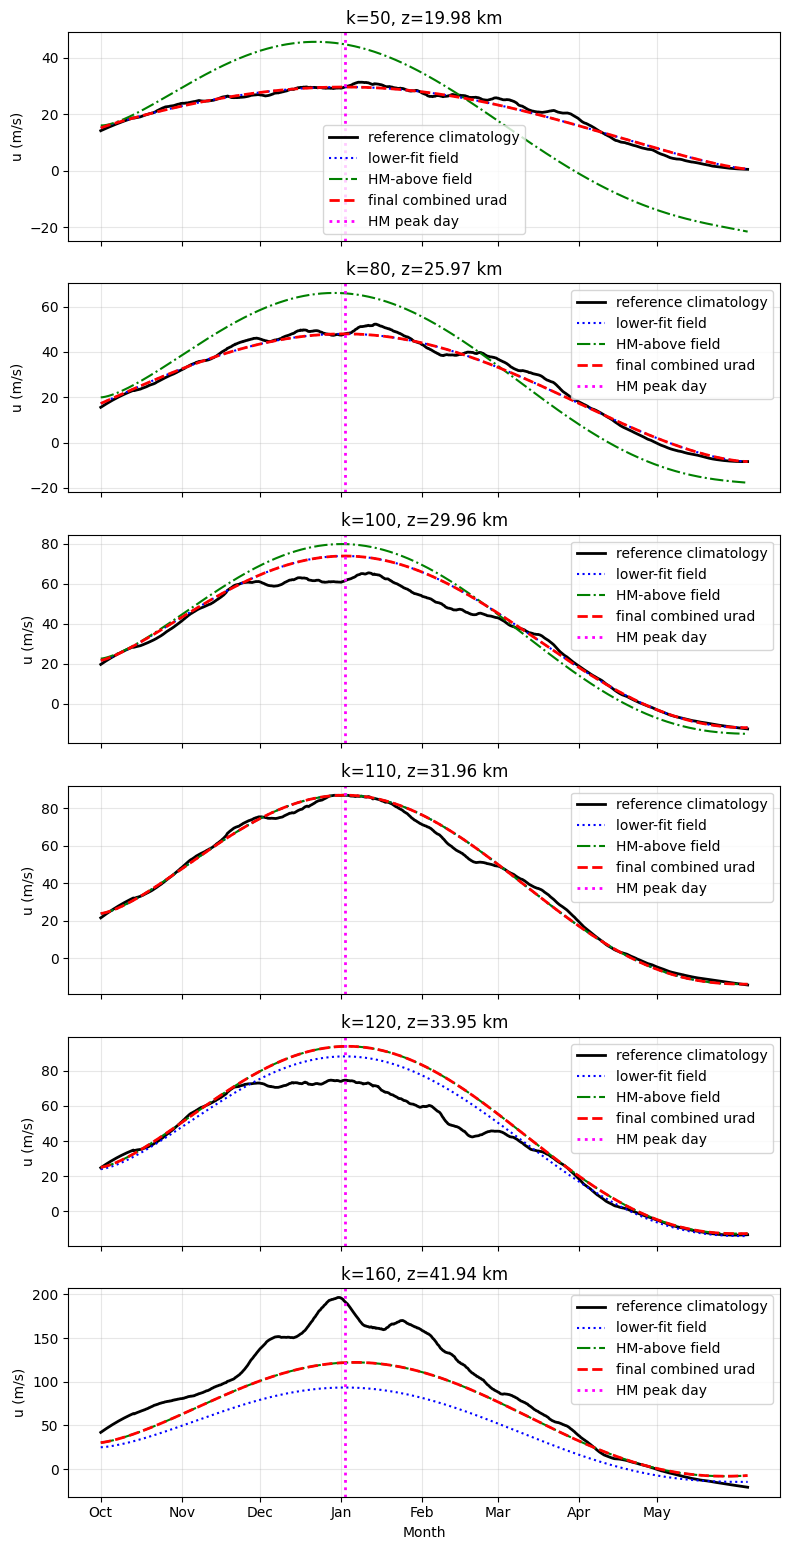

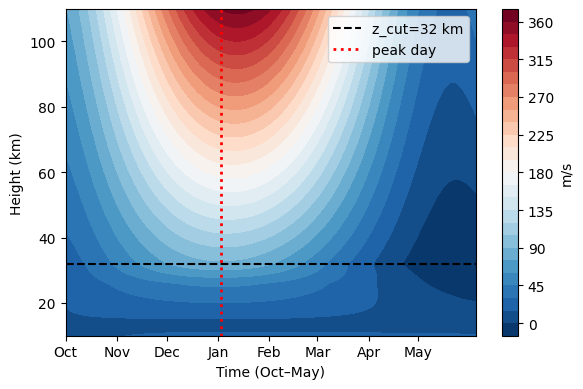

saved to: /nas/winds-home/smliu01/0.1dmodel_2025/urad/urad_below32_fit_above32_HMshear_501_42.nc


In [ ]:
# ## 42 year

# import numpy as np
# import matplotlib.pyplot as plt
# import netCDF4 as nc

# # =========================================================
# # user settings
# # =========================================================
# nyear = 42
# zdim  = 501
# ntime = 992



# ref_file = f'/nas/winds-home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/urad_{zdim}.nc'
# out_file = f'/nas/winds-home/smliu01/0.1dmodel_2025/urad/urad_below32_fit_above32_HMshear_{zdim}_{nyear}.nc'

# # =========================================================
# # lower-part fitting settings
# # IMPORTANT: only use anchors BELOW / AT 32 km
# # =========================================================
# k_ref = 110
# lower_anchors = [50, 80, 110]
# use_common_peak = True
# right_slope_factor_low = 0.1
# npass_smooth_low = 0

# # =========================================================
# # HM-style shear settings for above 32 km
# # =========================================================
# shear_min = 0.5
# shear_max = 3.6
# shear_scale = 1.0
# t_peak_hm = 107*4 #93.5 * 4

# # =========================================================
# # transition height
# # =========================================================
# z_cut = 32.0   # km
# blend_half_width_km = 0.0   # set 0 for hard switch

# # =========================================================
# # helper
# # =========================================================
# def smooth121_1d(x, npass=3):
#     x = np.asarray(x, dtype=float).copy()
#     if npass <= 0:
#         return x
#     for _ in range(npass):
#         y = x.copy()
#         for i in range(1, len(x)-1):
#             vals = np.array([x[i-1], x[i], x[i+1]], dtype=float)
#             w = np.array([1.0, 2.0, 1.0], dtype=float)
#             m = np.isfinite(vals)
#             if np.any(m):
#                 y[i] = np.sum(vals[m] * w[m]) / np.sum(w[m])
#         x = y
#     return x

# def piecewise_shape(t, t_peak, u_min, u_peak, u_end, p_pre, p_post, ntime):
#     t = np.asarray(t, dtype=float)
#     y = np.zeros_like(t, dtype=float)

#     # before peak
#     m1 = t <= t_peak
#     if np.any(m1):
#         x1 = np.zeros_like(t[m1], dtype=float)
#         if t_peak > 0:
#             x1 = t[m1] / t_peak
#         x1 = np.clip(x1, 0.0, 1.0)
#         y[m1] = u_min + (u_peak - u_min) * np.sin(0.5 * np.pi * x1) ** p_pre

#     # after peak
#     m2 = t > t_peak
#     if np.any(m2):
#         denom = (ntime - 1 - t_peak)
#         x2 = np.zeros_like(t[m2], dtype=float)
#         if denom > 0:
#             x2 = (ntime - 1 - t[m2]) / denom
#         x2 = np.clip(x2, 0.0, 1.0)
#         y[m2] = u_end + (u_peak - u_end) * np.sin(0.5 * np.pi * x2) ** p_post

#     return y

# def fit_piecewise_given_peak(y, t_peak, ntime, p_candidates=None):
#     if p_candidates is None:
#         p_candidates = np.arange(0.6, 3.01, 0.1)

#     t = np.arange(len(y))
#     y = np.asarray(y, dtype=float)

#     u_peak = y[t_peak]
#     u_min  = np.nanmean(y[:20])
#     u_end  = np.nanmean(y[-20:])

#     best = None
#     best_err = np.inf

#     for p_pre in p_candidates:
#         for p_post in p_candidates:
#             yfit = piecewise_shape(
#                 t=t, t_peak=t_peak,
#                 u_min=u_min, u_peak=u_peak, u_end=u_end,
#                 p_pre=p_pre, p_post=p_post,
#                 ntime=ntime
#             )
#             err = np.nanmean((y - yfit) ** 2)
#             if err < best_err:
#                 best_err = err
#                 best = (u_min, u_peak, u_end, p_pre, p_post, yfit)

#     return best, best_err

# def interp_piecewise_linear_scaled_right(x_new, x, y, right_slope_factor=0.35):
#     x_new = np.asarray(x_new, dtype=float)
#     x = np.asarray(x, dtype=float)
#     y = np.asarray(y, dtype=float)

#     y_new = np.empty_like(x_new, dtype=float)

#     # left extrapolation
#     slope_left = (y[1] - y[0]) / (x[1] - x[0])
#     m_left = x_new <= x[0]
#     y_new[m_left] = y[0] + slope_left * (x_new[m_left] - x[0])

#     # piecewise linear interpolation inside
#     for i in range(len(x) - 1):
#         m = (x_new > x[i]) & (x_new <= x[i+1])
#         frac = (x_new[m] - x[i]) / (x[i+1] - x[i])
#         y_new[m] = y[i] + frac * (y[i+1] - y[i])

#     # exact first anchor
#     y_new[x_new == x[0]] = y[0]

#     # right extrapolation
#     slope_right = (y[-1] - y[-2]) / (x[-1] - x[-2])
#     slope_right_scaled = right_slope_factor * slope_right
#     m_right = x_new > x[-1]
#     y_new[m_right] = y[-1] + slope_right_scaled * (x_new[m_right] - x[-1])

#     return y_new

# # =========================================================
# # vertical grid
# # =========================================================
# hhh = np.arange(zdim) * (100.0 / zdim) + 10.0   # km
# k_all = np.arange(zdim, dtype=float)

# k_cut = int(np.argmin(np.abs(hhh - z_cut)))
# z_cut_actual = hhh[k_cut]

# print(f"Requested z_cut = {z_cut:.2f} km")
# print(f"Actual nearest grid point: k_cut = {k_cut}, z_cut_actual = {z_cut_actual:.3f} km")

# # =========================================================
# # time axis
# # =========================================================
# t_idx = np.arange(ntime)
# t_days = t_idx / 4.0
# t = np.arange(ntime)

# # =========================================================
# # load reference
# # =========================================================
# ds = nc.Dataset(ref_file, 'r')
# urad_ref = np.array(ds.variables['urad'][:], dtype=float)
# ds.close()

# urad_clim = np.nanmean(urad_ref, axis=1)
# print("urad_clim shape =", urad_clim.shape)

# # =========================================================
# # fit ONLY lower anchors [50,80,110]
# # =========================================================
# t_peak_common = int(np.nanargmax(urad_clim[k_ref, :])) if use_common_peak else None
# print("common lower t_peak =", t_peak_common, "day =", t_peak_common/4.0 if t_peak_common is not None else None)

# lower_anchor_params = {}

# for k in lower_anchors:
#     y = urad_clim[k, :]

#     if use_common_peak:
#         tpk = t_peak_common
#     else:
#         tpk = int(np.nanargmax(y))

#     best, err = fit_piecewise_given_peak(y, tpk, ntime=ntime)
#     u_min, u_peak, u_end, p_pre, p_post, yfit = best

#     lower_anchor_params[k] = {
#         't_peak': tpk,
#         'u_min': u_min,
#         'u_peak': u_peak,
#         'u_end': u_end,
#         'p_pre': p_pre,
#         'p_post': p_post,
#         'fit': yfit,
#         'mse': err
#     }

#     print(
#         f"LOW k={k:3d}, z={hhh[k]:6.2f} km, "
#         f"t_peak={tpk:4d}, "
#         f"u_min={u_min:8.3f}, u_peak={u_peak:8.3f}, u_end={u_end:8.3f}, "
#         f"p_pre={p_pre:5.2f}, p_post={p_post:5.2f}, mse={err:9.4f}"
#     )

# # =========================================================
# # build lower fitted field using ONLY lower anchors
# # =========================================================
# k_anchor_low = np.array(lower_anchors, dtype=float)

# u_min_anchor_low  = np.array([lower_anchor_params[k]['u_min']  for k in lower_anchors], dtype=float)
# u_peak_anchor_low = np.array([lower_anchor_params[k]['u_peak'] for k in lower_anchors], dtype=float)
# u_end_anchor_low  = np.array([lower_anchor_params[k]['u_end']  for k in lower_anchors], dtype=float)
# p_pre_anchor_low  = np.array([lower_anchor_params[k]['p_pre']  for k in lower_anchors], dtype=float)
# p_post_anchor_low = np.array([lower_anchor_params[k]['p_post'] for k in lower_anchors], dtype=float)
# t_peak_anchor_low = np.array([lower_anchor_params[k]['t_peak'] for k in lower_anchors], dtype=float)

# u_min_prof_low  = interp_piecewise_linear_scaled_right(k_all, k_anchor_low, u_min_anchor_low,  right_slope_factor=right_slope_factor_low)
# u_peak_prof_low = interp_piecewise_linear_scaled_right(k_all, k_anchor_low, u_peak_anchor_low, right_slope_factor=right_slope_factor_low)
# u_end_prof_low  = interp_piecewise_linear_scaled_right(k_all, k_anchor_low, u_end_anchor_low,  right_slope_factor=right_slope_factor_low)
# p_pre_prof_low  = interp_piecewise_linear_scaled_right(k_all, k_anchor_low, p_pre_anchor_low,  right_slope_factor=right_slope_factor_low)
# p_post_prof_low = interp_piecewise_linear_scaled_right(k_all, k_anchor_low, p_post_anchor_low, right_slope_factor=right_slope_factor_low)
# t_peak_prof_low = interp_piecewise_linear_scaled_right(k_all, k_anchor_low, t_peak_anchor_low, right_slope_factor=0.0)

# u_min_prof_low  = smooth121_1d(u_min_prof_low,  npass=npass_smooth_low)
# u_peak_prof_low = smooth121_1d(u_peak_prof_low, npass=npass_smooth_low)
# u_end_prof_low  = smooth121_1d(u_end_prof_low,  npass=npass_smooth_low)
# p_pre_prof_low  = smooth121_1d(p_pre_prof_low,  npass=npass_smooth_low)
# p_post_prof_low = smooth121_1d(p_post_prof_low, npass=npass_smooth_low)

# u_peak_prof_low = np.maximum(u_peak_prof_low, u_min_prof_low + 1.0)
# u_peak_prof_low = np.maximum(u_peak_prof_low, u_end_prof_low + 1.0)

# urad_fit_low_2d = np.zeros((zdim, ntime), dtype=float)

# for k in range(zdim):
#     tpk_use = int(np.round(t_peak_prof_low[k]))
#     tpk_use = max(1, min(ntime - 2, tpk_use))

#     urad_fit_low_2d[k, :] = piecewise_shape(
#         t=t,
#         t_peak=tpk_use,
#         u_min=u_min_prof_low[k],
#         u_peak=u_peak_prof_low[k],
#         u_end=u_end_prof_low[k],
#         p_pre=p_pre_prof_low[k],
#         p_post=p_post_prof_low[k],
#         ntime=ntime
#     )

# # =========================================================
# # HM seasonal shear for ABOVE 32 km, anchored at z_cut
# # =========================================================
# phase = np.cos(2.0 * np.pi * (t_idx - t_peak_hm) / ntime)
# phase01 = 0.5 * (phase + 1.0)
# shear_t = shear_min + (shear_max - shear_min) * phase01
# shear_t = shear_scale * shear_t

# print("shear_t min/max =", shear_t.min(), shear_t.max())

# urad_hm_above_2d = np.zeros((zdim, ntime), dtype=float)
# for it in range(ntime):
#     urad_hm_above_2d[:, it] = urad_fit_low_2d[k_cut, it] + shear_t[it] * (hhh - z_cut_actual)

# # =========================================================
# # final combine
# # =========================================================
# urad_new_2d = np.zeros((zdim, ntime), dtype=float)

# if blend_half_width_km <= 0.0:
#     mask_low = hhh <= z_cut_actual
#     mask_high = hhh > z_cut_actual
#     urad_new_2d[mask_low, :] = urad_fit_low_2d[mask_low, :]
#     urad_new_2d[mask_high, :] = urad_hm_above_2d[mask_high, :]
# else:
#     z1 = z_cut_actual - blend_half_width_km
#     z2 = z_cut_actual + blend_half_width_km
#     for k in range(zdim):
#         z = hhh[k]
#         if z <= z1:
#             urad_new_2d[k, :] = urad_fit_low_2d[k, :]
#         elif z >= z2:
#             urad_new_2d[k, :] = urad_hm_above_2d[k, :]
#         else:
#             w = (z - z1) / (z2 - z1)
#             urad_new_2d[k, :] = (1.0 - w) * urad_fit_low_2d[k, :] + w * urad_hm_above_2d[k, :]

# # =========================================================
# # expand to all years
# # =========================================================
# urad_new_3d = np.repeat(urad_new_2d[:, np.newaxis, :], nyear, axis=1)

# print("urad_new_2d shape =", urad_new_2d.shape)
# print("urad_new_3d shape =", urad_new_3d.shape)
# print("new urad min/max =", np.nanmin(urad_new_3d), np.nanmax(urad_new_3d))

# # =========================================================
# # plots
# # =========================================================
# month_ticks = [0, 31, 61, 92, 123, 152, 183, 213]
# month_labels = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May']

# levels_to_plot = [50, 80, 100, k_cut, 120, 160]
# fig, axes = plt.subplots(len(levels_to_plot), 1, figsize=(8, 2.6*len(levels_to_plot)), sharex=True)
# if len(levels_to_plot) == 1:
#     axes = [axes]

# for ax, k in zip(axes, levels_to_plot):
#     ax.plot(t_days, urad_clim[k, :], color='k', lw=2, label='reference climatology')
#     ax.plot(t_days, urad_fit_low_2d[k, :], color='blue', lw=1.5, ls=':', label='lower-fit field')
#     ax.plot(t_days, urad_hm_above_2d[k, :], color='green', lw=1.5, ls='-.', label='HM-above field')
#     ax.plot(t_days, urad_new_2d[k, :], color='red', lw=2, ls='--', label='final combined urad')
#     # peak day
#     if 't_peak_hm' in locals():
#         peak_day = t_peak_hm
#         ax.axvline(93.5, color='magenta', ls=':', lw=2, label='HM peak day')
#     ax.set_ylabel('u (m/s)')
#     ax.set_title(f'k={k}, z={hhh[k]:.2f} km')
#     ax.grid(alpha=0.3)
#     ax.legend()

# axes[-1].set_xticks(month_ticks)
# axes[-1].set_xticklabels(month_labels)
# axes[-1].set_xlabel('Month')
# plt.tight_layout()
# plt.show()

# # t-z contour
# T, Z = np.meshgrid(t_days, hhh)

# plt.figure(figsize=(6,4))
# cf = plt.contourf(T, Z, urad_new_2d, levels=31, cmap='RdBu_r')
# plt.colorbar(cf, label=r'm/s')
# plt.axhline(z_cut_actual, color='k', ls='--', lw=1.5, label=f'z_cut=32 km')
# # peak day
# if 't_peak_hm' in locals():
#     plt.axvline(93.5, color='red', ls=':', lw=2, label='peak day')
# plt.xticks(month_ticks, month_labels)
# plt.xlabel('Time (Oct–May)')
# plt.ylabel('Height (km)')
# #plt.title(r'Below 32 km: lower-anchor fit only; Above 32 km: HM shear')
# plt.legend()
# plt.tight_layout()
# plt.savefig("urad_hm.png", bbox_inches="tight", dpi=600)
# plt.show()

# # =========================================================
# # save to netCDF
# # =========================================================
# ncfile = nc.Dataset(out_file, mode='w', format='NETCDF4')

# ncfile.createDimension('height', zdim)
# ncfile.createDimension('year', nyear)
# ncfile.createDimension('time', ntime)

# height_var = ncfile.createVariable('height', np.float32, ('height',))
# year_var   = ncfile.createVariable('year', np.int32, ('year',))
# time_var   = ncfile.createVariable('time', np.int32, ('time',))
# urad_var   = ncfile.createVariable('urad', np.float32, ('height', 'year', 'time'))

# height_var[:] = hhh
# year_var[:]   = np.arange(nyear)
# time_var[:]   = np.arange(ntime)
# urad_var[:]   = urad_new_3d.astype(np.float32)

# height_var.units = 'km'
# height_var.long_name = 'height'
# year_var.long_name = 'year index'
# time_var.long_name = '6-hourly time index from Oct 1'
# urad_var.units = 'm s-1'
# urad_var.long_name = 'combined urad: below 32 km lower-anchor fit only, above 32 km HM shear'

# ncfile.close()

# print("saved to:", out_file)

Requested z_cut = 32.00 km
Actual nearest grid point: k_cut = 110, z_cut_actual = 31.956 km
urad_clim shape = (501, 992)
common lower t_peak = 374 day = 93.5
LOW k= 50, z= 19.98 km, t_peak= 374, u_min=  15.207, u_peak=  29.708, u_end=   0.650, p_pre= 0.90, p_post= 1.30, mse=   1.4470
LOW k= 80, z= 25.97 km, t_peak= 374, u_min=  17.261, u_peak=  47.956, u_end=  -8.346, p_pre= 1.00, p_post= 1.60, mse=   4.3465
LOW k=110, z= 31.96 km, t_peak= 374, u_min=  23.808, u_peak=  86.864, u_end= -13.868, p_pre= 1.40, p_post= 2.40, mse=   8.4865
shear_t min/max = 0.5 3.6
urad_new_2d shape = (501, 992)
urad_new_3d shape = (501, 1000, 992)
new urad min/max = -13.868218183517456 365.3837220907045


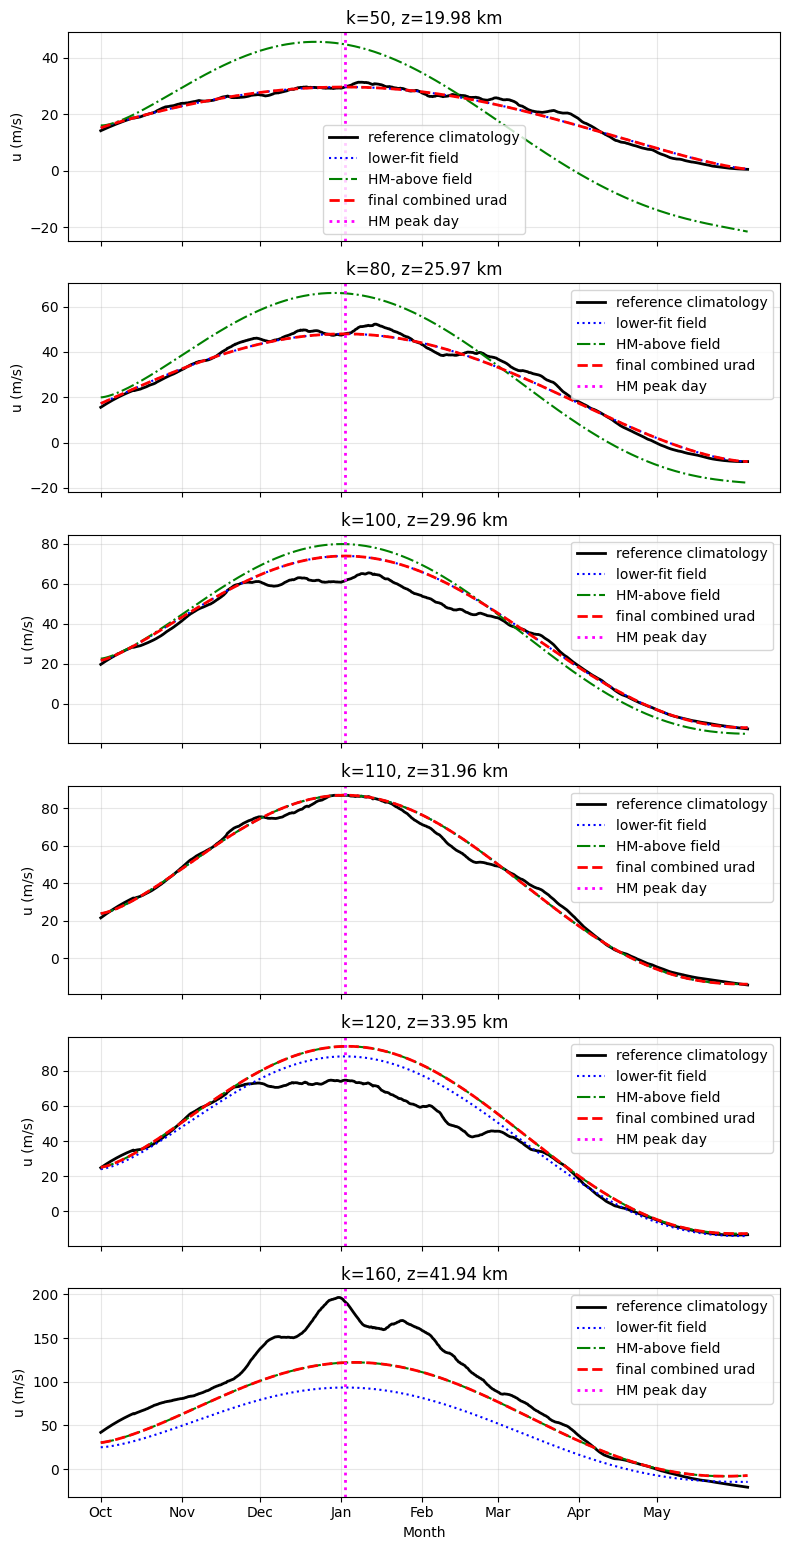

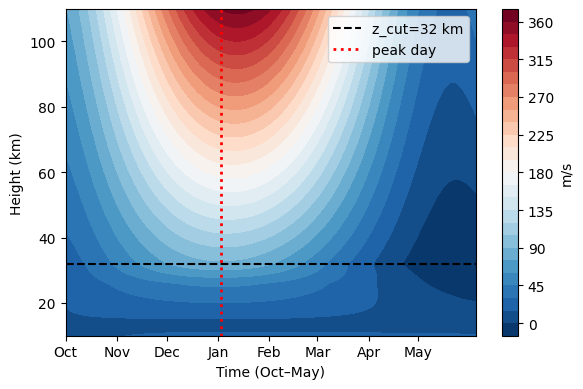

In [ ]:
# ## 1000 year

# import numpy as np
# import matplotlib.pyplot as plt
# import netCDF4 as nc

# # =========================================================
# # user settings
# # =========================================================
# nyear = 1000
# zdim  = 501
# ntime = 992

# ref_file = f'/nas/winds-home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/urad_{zdim}.nc'
# out_file = f'/nas/winds-home/smliu01/0.1dmodel_2025/urad/urad_below32_fit_above32_HMshear_{zdim}_{nyear}.nc'

# # =========================================================
# # lower-part fitting settings
# # IMPORTANT: only use anchors BELOW / AT 32 km
# # =========================================================
# k_ref = 110
# lower_anchors = [50, 80, 110]
# use_common_peak = True
# right_slope_factor_low = 0.1
# npass_smooth_low = 0

# # =========================================================
# # HM-style shear settings for above 32 km
# # =========================================================
# shear_min = 0.5
# shear_max = 3.6
# shear_scale = 1.0
# t_peak_hm = 107 * 4

# # =========================================================
# # transition height
# # =========================================================
# z_cut = 32.0   # km
# blend_half_width_km = 0.0   # set 0 for hard switch

# # =========================================================
# # helper
# # =========================================================
# def smooth121_1d(x, npass=3):
#     x = np.asarray(x, dtype=float).copy()
#     if npass <= 0:
#         return x
#     for _ in range(npass):
#         y = x.copy()
#         for i in range(1, len(x)-1):
#             vals = np.array([x[i-1], x[i], x[i+1]], dtype=float)
#             w = np.array([1.0, 2.0, 1.0], dtype=float)
#             m = np.isfinite(vals)
#             if np.any(m):
#                 y[i] = np.sum(vals[m] * w[m]) / np.sum(w[m])
#         x = y
#     return x

# def piecewise_shape(t, t_peak, u_min, u_peak, u_end, p_pre, p_post, ntime):
#     t = np.asarray(t, dtype=float)
#     y = np.zeros_like(t, dtype=float)

#     # before peak
#     m1 = t <= t_peak
#     if np.any(m1):
#         x1 = np.zeros_like(t[m1], dtype=float)
#         if t_peak > 0:
#             x1 = t[m1] / t_peak
#         x1 = np.clip(x1, 0.0, 1.0)
#         y[m1] = u_min + (u_peak - u_min) * np.sin(0.5 * np.pi * x1) ** p_pre

#     # after peak
#     m2 = t > t_peak
#     if np.any(m2):
#         denom = (ntime - 1 - t_peak)
#         x2 = np.zeros_like(t[m2], dtype=float)
#         if denom > 0:
#             x2 = (ntime - 1 - t[m2]) / denom
#         x2 = np.clip(x2, 0.0, 1.0)
#         y[m2] = u_end + (u_peak - u_end) * np.sin(0.5 * np.pi * x2) ** p_post

#     return y

# def fit_piecewise_given_peak(y, t_peak, ntime, p_candidates=None):
#     if p_candidates is None:
#         p_candidates = np.arange(0.6, 3.01, 0.1)

#     t = np.arange(len(y))
#     y = np.asarray(y, dtype=float)

#     u_peak = y[t_peak]
#     u_min  = np.nanmean(y[:20])
#     u_end  = np.nanmean(y[-20:])

#     best = None
#     best_err = np.inf

#     for p_pre in p_candidates:
#         for p_post in p_candidates:
#             yfit = piecewise_shape(
#                 t=t, t_peak=t_peak,
#                 u_min=u_min, u_peak=u_peak, u_end=u_end,
#                 p_pre=p_pre, p_post=p_post,
#                 ntime=ntime
#             )
#             err = np.nanmean((y - yfit) ** 2)
#             if err < best_err:
#                 best_err = err
#                 best = (u_min, u_peak, u_end, p_pre, p_post, yfit)

#     return best, best_err

# def interp_piecewise_linear_scaled_right(x_new, x, y, right_slope_factor=0.35):
#     x_new = np.asarray(x_new, dtype=float)
#     x = np.asarray(x, dtype=float)
#     y = np.asarray(y, dtype=float)

#     y_new = np.empty_like(x_new, dtype=float)

#     # left extrapolation
#     slope_left = (y[1] - y[0]) / (x[1] - x[0])
#     m_left = x_new <= x[0]
#     y_new[m_left] = y[0] + slope_left * (x_new[m_left] - x[0])

#     # piecewise linear interpolation inside
#     for i in range(len(x) - 1):
#         m = (x_new > x[i]) & (x_new <= x[i+1])
#         frac = (x_new[m] - x[i]) / (x[i+1] - x[i])
#         y_new[m] = y[i] + frac * (y[i+1] - y[i])

#     # exact first anchor
#     y_new[x_new == x[0]] = y[0]

#     # right extrapolation
#     slope_right = (y[-1] - y[-2]) / (x[-1] - x[-2])
#     slope_right_scaled = right_slope_factor * slope_right
#     m_right = x_new > x[-1]
#     y_new[m_right] = y[-1] + slope_right_scaled * (x_new[m_right] - x[-1])

#     return y_new

# # =========================================================
# # vertical grid
# # =========================================================
# hhh = np.arange(zdim) * (100.0 / zdim) + 10.0   # km
# k_all = np.arange(zdim, dtype=float)

# k_cut = int(np.argmin(np.abs(hhh - z_cut)))
# z_cut_actual = hhh[k_cut]

# print(f"Requested z_cut = {z_cut:.2f} km")
# print(f"Actual nearest grid point: k_cut = {k_cut}, z_cut_actual = {z_cut_actual:.3f} km")

# # =========================================================
# # time axis
# # =========================================================
# t_idx = np.arange(ntime)
# t_days = t_idx / 4.0
# t = np.arange(ntime)

# # =========================================================
# # load reference
# # =========================================================
# ds = nc.Dataset(ref_file, 'r')
# urad_ref = np.array(ds.variables['urad'][:], dtype=float)
# ds.close()

# urad_clim = np.nanmean(urad_ref, axis=1)
# print("urad_clim shape =", urad_clim.shape)

# # =========================================================
# # fit ONLY lower anchors [50,80,110]
# # =========================================================
# t_peak_common = int(np.nanargmax(urad_clim[k_ref, :])) if use_common_peak else None
# print("common lower t_peak =", t_peak_common, "day =", t_peak_common/4.0 if t_peak_common is not None else None)

# lower_anchor_params = {}

# for k in lower_anchors:
#     y = urad_clim[k, :]

#     if use_common_peak:
#         tpk = t_peak_common
#     else:
#         tpk = int(np.nanargmax(y))

#     best, err = fit_piecewise_given_peak(y, tpk, ntime=ntime)
#     u_min, u_peak, u_end, p_pre, p_post, yfit = best

#     lower_anchor_params[k] = {
#         't_peak': tpk,
#         'u_min': u_min,
#         'u_peak': u_peak,
#         'u_end': u_end,
#         'p_pre': p_pre,
#         'p_post': p_post,
#         'fit': yfit,
#         'mse': err
#     }

#     print(
#         f"LOW k={k:3d}, z={hhh[k]:6.2f} km, "
#         f"t_peak={tpk:4d}, "
#         f"u_min={u_min:8.3f}, u_peak={u_peak:8.3f}, u_end={u_end:8.3f}, "
#         f"p_pre={p_pre:5.2f}, p_post={p_post:5.2f}, mse={err:9.4f}"
#     )

# # =========================================================
# # build lower fitted field using ONLY lower anchors
# # =========================================================
# k_anchor_low = np.array(lower_anchors, dtype=float)

# u_min_anchor_low  = np.array([lower_anchor_params[k]['u_min']  for k in lower_anchors], dtype=float)
# u_peak_anchor_low = np.array([lower_anchor_params[k]['u_peak'] for k in lower_anchors], dtype=float)
# u_end_anchor_low  = np.array([lower_anchor_params[k]['u_end']  for k in lower_anchors], dtype=float)
# p_pre_anchor_low  = np.array([lower_anchor_params[k]['p_pre']  for k in lower_anchors], dtype=float)
# p_post_anchor_low = np.array([lower_anchor_params[k]['p_post'] for k in lower_anchors], dtype=float)
# t_peak_anchor_low = np.array([lower_anchor_params[k]['t_peak'] for k in lower_anchors], dtype=float)

# u_min_prof_low  = interp_piecewise_linear_scaled_right(k_all, k_anchor_low, u_min_anchor_low,  right_slope_factor=right_slope_factor_low)
# u_peak_prof_low = interp_piecewise_linear_scaled_right(k_all, k_anchor_low, u_peak_anchor_low, right_slope_factor=right_slope_factor_low)
# u_end_prof_low  = interp_piecewise_linear_scaled_right(k_all, k_anchor_low, u_end_anchor_low,  right_slope_factor=right_slope_factor_low)
# p_pre_prof_low  = interp_piecewise_linear_scaled_right(k_all, k_anchor_low, p_pre_anchor_low,  right_slope_factor=right_slope_factor_low)
# p_post_prof_low = interp_piecewise_linear_scaled_right(k_all, k_anchor_low, p_post_anchor_low, right_slope_factor=right_slope_factor_low)
# t_peak_prof_low = interp_piecewise_linear_scaled_right(k_all, k_anchor_low, t_peak_anchor_low, right_slope_factor=0.0)

# u_min_prof_low  = smooth121_1d(u_min_prof_low,  npass=npass_smooth_low)
# u_peak_prof_low = smooth121_1d(u_peak_prof_low, npass=npass_smooth_low)
# u_end_prof_low  = smooth121_1d(u_end_prof_low,  npass=npass_smooth_low)
# p_pre_prof_low  = smooth121_1d(p_pre_prof_low,  npass=npass_smooth_low)
# p_post_prof_low = smooth121_1d(p_post_prof_low, npass=npass_smooth_low)

# u_peak_prof_low = np.maximum(u_peak_prof_low, u_min_prof_low + 1.0)
# u_peak_prof_low = np.maximum(u_peak_prof_low, u_end_prof_low + 1.0)

# urad_fit_low_2d = np.zeros((zdim, ntime), dtype=float)

# for k in range(zdim):
#     tpk_use = int(np.round(t_peak_prof_low[k]))
#     tpk_use = max(1, min(ntime - 2, tpk_use))

#     urad_fit_low_2d[k, :] = piecewise_shape(
#         t=t,
#         t_peak=tpk_use,
#         u_min=u_min_prof_low[k],
#         u_peak=u_peak_prof_low[k],
#         u_end=u_end_prof_low[k],
#         p_pre=p_pre_prof_low[k],
#         p_post=p_post_prof_low[k],
#         ntime=ntime
#     )

# # =========================================================
# # HM seasonal shear for ABOVE 32 km, anchored at z_cut
# # =========================================================
# phase = np.cos(2.0 * np.pi * (t_idx - t_peak_hm) / ntime)
# phase01 = 0.5 * (phase + 1.0)
# shear_t = shear_min + (shear_max - shear_min) * phase01
# shear_t = shear_scale * shear_t

# print("shear_t min/max =", shear_t.min(), shear_t.max())

# urad_hm_above_2d = np.zeros((zdim, ntime), dtype=float)
# for it in range(ntime):
#     urad_hm_above_2d[:, it] = urad_fit_low_2d[k_cut, it] + shear_t[it] * (hhh - z_cut_actual)

# # =========================================================
# # final combine
# # =========================================================
# urad_new_2d = np.zeros((zdim, ntime), dtype=float)

# if blend_half_width_km <= 0.0:
#     mask_low = hhh <= z_cut_actual
#     mask_high = hhh > z_cut_actual
#     urad_new_2d[mask_low, :] = urad_fit_low_2d[mask_low, :]
#     urad_new_2d[mask_high, :] = urad_hm_above_2d[mask_high, :]
# else:
#     z1 = z_cut_actual - blend_half_width_km
#     z2 = z_cut_actual + blend_half_width_km
#     for k in range(zdim):
#         z = hhh[k]
#         if z <= z1:
#             urad_new_2d[k, :] = urad_fit_low_2d[k, :]
#         elif z >= z2:
#             urad_new_2d[k, :] = urad_hm_above_2d[k, :]
#         else:
#             w = (z - z1) / (z2 - z1)
#             urad_new_2d[k, :] = (1.0 - w) * urad_fit_low_2d[k, :] + w * urad_hm_above_2d[k, :]

# # =========================================================
# # expand to all years
# # =========================================================
# urad_new_3d = np.repeat(urad_new_2d[:, np.newaxis, :], nyear, axis=1)

# print("urad_new_2d shape =", urad_new_2d.shape)
# print("urad_new_3d shape =", urad_new_3d.shape)
# print("new urad min/max =", np.nanmin(urad_new_3d), np.nanmax(urad_new_3d))

# # =========================================================
# # plots
# # =========================================================
# month_ticks = [0, 31, 61, 92, 123, 152, 183, 213]
# month_labels = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May']

# levels_to_plot = [50, 80, 100, k_cut, 120, 160]
# fig, axes = plt.subplots(len(levels_to_plot), 1, figsize=(8, 2.6*len(levels_to_plot)), sharex=True)
# if len(levels_to_plot) == 1:
#     axes = [axes]

# for ax, k in zip(axes, levels_to_plot):
#     ax.plot(t_days, urad_clim[k, :], color='k', lw=2, label='reference climatology')
#     ax.plot(t_days, urad_fit_low_2d[k, :], color='blue', lw=1.5, ls=':', label='lower-fit field')
#     ax.plot(t_days, urad_hm_above_2d[k, :], color='green', lw=1.5, ls='-.', label='HM-above field')
#     ax.plot(t_days, urad_new_2d[k, :], color='red', lw=2, ls='--', label='final combined urad')
#     # peak day
#     if 't_peak_hm' in locals():
#         peak_day = t_peak_hm
#         ax.axvline(93.5, color='magenta', ls=':', lw=2, label='HM peak day')
#     ax.set_ylabel('u (m/s)')
#     ax.set_title(f'k={k}, z={hhh[k]:.2f} km')
#     ax.grid(alpha=0.3)
#     ax.legend()

# axes[-1].set_xticks(month_ticks)
# axes[-1].set_xticklabels(month_labels)
# axes[-1].set_xlabel('Month')
# plt.tight_layout()
# plt.show()

# # t-z contour
# T, Z = np.meshgrid(t_days, hhh)

# plt.figure(figsize=(6,4))
# cf = plt.contourf(T, Z, urad_new_2d, levels=31, cmap='RdBu_r')
# plt.colorbar(cf, label=r'm/s')
# plt.axhline(z_cut_actual, color='k', ls='--', lw=1.5, label=f'z_cut=32 km')
# # peak day
# if 't_peak_hm' in locals():
#     plt.axvline(93.5, color='red', ls=':', lw=2, label='peak day')
# plt.xticks(month_ticks, month_labels)
# plt.xlabel('Time (Oct–May)')
# plt.ylabel('Height (km)')
# #plt.title(r'Below 32 km: lower-anchor fit only; Above 32 km: HM shear')
# plt.legend()
# plt.tight_layout()
# plt.savefig("urad_hm.png", bbox_inches="tight", dpi=600)
# plt.show()



In [1]:
# import numpy as np
# import matplotlib.pyplot as plt

# # =========================================================
# # settings
# # =========================================================
# ntime = 992
# t_idx = np.arange(ntime)

# # peak around mid-Jan
# t_peak = 107 * 4

# # asymmetric seasonal shear (m/s/km)
# shear_min = 2.2
# shear_max = 3.4

# # shape parameters
# p_rise  = 0.9   # Oct -> Jan, smaller = faster early rise
# p_decay = 1.6   # Jan -> May, larger = slower early decay, faster later decay

# # =========================================================
# # build asymmetric shear(t)
# # =========================================================
# shear_t = np.zeros(ntime)

# for it in range(ntime):
#     if it <= t_peak:
#         x = it / t_peak   # 0 -> 1
#         shear_t[it] = shear_min + (shear_max - shear_min) * np.sin(0.5*np.pi*x)**p_rise
#     else:
#         x = (it - t_peak) / (ntime - 1 - t_peak)   # 0 -> 1
#         shear_t[it] = shear_max - (shear_max - shear_min) * np.sin(0.5*np.pi*x)**p_decay

# # =========================================================
# # plot shear
# # =========================================================
# plt.figure(figsize=(7,4))
# plt.plot(t_idx/4.0, shear_t, linewidth=2)
# plt.xticks(
#     ticks=[0,31,61,92,123,152,183,213],
#     labels=['Oct','Nov','Dec','Jan','Feb','Mar','Apr','May']
# )
# plt.xlabel('Month')
# plt.ylabel('Shear (m/s/km)')
# plt.title('Asymmetric seasonal shear')
# plt.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()

In [2]:
# import numpy as np
# import matplotlib.pyplot as plt

# # =========================================================
# # settings
# # =========================================================
# zdim = 501
# ntime = 992
# nyear = 1000

# hhh = np.arange(zdim) * (100.0 / zdim) + 10.0   # km

# u10 = 12.0   # HM value at 10 km

# # =========================================================
# # use the shear_t built above
# # =========================================================
# urad_hm_2d = u10 + np.outer(hhh - 10.0, shear_t)   # (zdim, 992)

# # repeat across years
# urad_hm_3d = np.repeat(urad_hm_2d[:, np.newaxis, :], nyear, axis=1)

# print("urad_hm_2d shape =", urad_hm_2d.shape)
# print("urad_hm_3d shape =", urad_hm_3d.shape)
# print("min/max =", np.nanmin(urad_hm_3d), np.nanmax(urad_hm_3d))

In [3]:
# T, Z = np.meshgrid(np.arange(ntime)/4.0, hhh)

# plt.figure(figsize=(9,6))
# cf = plt.contourf(T, Z, urad_hm_2d, levels=31)
# plt.colorbar(cf, label=r'$U_{rad}$ (m/s)')
# plt.xticks(
#     ticks=[0,31,61,92,123,152,183,213],
#     labels=['Oct','Nov','Dec','Jan','Feb','Mar','Apr','May']
# )
# plt.xlabel('Month')
# plt.ylabel('Height (km)')
# plt.title('HM-style $U_{rad}(z,t)$ with asymmetric seasonal shear')
# plt.tight_layout()
# plt.show()

In [4]:
# x = np.arange(ntime) / 4.0

# k_plot = 110   # example index
# plot.figure(figsize=(6,3))
# plot.plot(x, urad_hm_2d[k_plot, :], color='red', label='HM seasonal urad')
# plot.xticks(
#     ticks=[0,31,61,92,123,152,183,213],
#     labels=['Oct','Nov','Dec','Jan','Feb','Mar','Apr','May']
# )
# plot.xlabel('Month')
# plot.ylabel('wind (m/s)')
# plot.legend()
# plot.tight_layout()
# plot.show()